In [160]:
import pandas as pd
import numpy as np
import graphviz
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats
import warnings

from statsmodels.formula.api import ols
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot, add_constant
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 환경에서는 'Malgun Gothic' 폰트를 사용
else:
    plt.rcParams['font.family'] = 'AppleGothic'  # macOS나 Linux 등 다른 환경에서는 'AppleGothic' 폰트를 사용

matplotlib.rcParams['axes.unicode_minus'] = False

In [161]:
#데이터 불러오기
df_1= pd.read_csv("C:\\BigDataProgramming\\sts_1sm_cc_1.csv", encoding = 'euc-kr')
df_2= pd.read_csv("C:\\BigDataProgramming\\sts_2fur_hr_2.csv", encoding = 'euc-kr')
df_3= pd.read_csv("C:\\BigDataProgramming\\sts_3ap_3.csv", encoding = 'euc-kr')

In [162]:
# 컬럼별 결측값 개수
display(df_1.isnull().sum())
# 14개
# 결측값이 있는 행만 보기
df_1[df_1.isnull().any(axis=1)]

sm_plant         0
charge_id        0
steel_grade      0
steel_usage      0
delta_ferrite    0
ingre_cr         0
ingre_ni         0
ingre_s          0
cast_date        0
cc_gubun         0
tundish_temp     2
mlac_ratio       3
slab_no          0
slab_gubun       0
slab_grind       9
dtype: int64

,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
14,1공장,CH80156,C13,RJ1,78,18.57,8.24,0.02,2025-07-13,2연주,1488.0,98.7,111,M,NaN
15,1공장,CH80156,C13,RJ1,78,18.57,8.24,0.02,2025-07-13,2연주,1488.0,NaN,211,M,NaN
16,1공장,CH80156,C13,RJ1,75,18.57,8.24,0.02,2025-07-13,2연주,0.0,98.7,311,M,NaN
39,1공장,CH80164,C13,Other,73,18.39,8.30,0.03,2025-07-13,2연주,520.0,97.5,611,C,NaN
40,1공장,CH80164,C13,Other,73,18.39,8.30,0.03,2025-07-13,2연주,1488.0,NaN,711,C,MISS
239,1공장,CH80441,C13,RJ1,74,18.50,8.27,0.06,2025-07-30,2연주,NaN,0.0,211,C,NaN
240,1공장,CH80441,C13,RJ1,74,18.50,8.27,0.06,2025-07-30,2연주,1491.0,NaN,311,C,NaN
241,1공장,CH80441,C13,RJ1,74,18.50,8.27,0.06,2025-07-30,2연주,1491.0,120.0,411,C,NaN
1785,1공장,CH81002,C13,RJ1,69,18.27,8.24,0.06,2025-07-24,2연주,NaN,99.5,211,C,HSHS
1786,1공장,CH81002,C13,RJ1,69,18.27,8.24,0.06,2025-07-24,2연주,1484.0,0.0,311,C,NaN


In [163]:
df_1.loc[df_1.isnull().any(axis=1), 'charge_id']
#CH80156 -> U708914
#CH80164-> U676944
#CH80441 -> U687944
#CH81002 -> V698634
#모두 양품

14      CH80156
15      CH80156
16      CH80156
39      CH80164
40      CH80164
239     CH80441
240     CH80441
241     CH80441
1785    CH81002
1786    CH81002
1787    CH81002
Name: charge_id, dtype: object

In [164]:
# 컬럼별 결측값 개수
display(df_2.isnull().sum())

# 결측값이 있는 행만 보기
df_2[df_2.isnull().any(axis=1)]

charge_id          0
slab_no            0
furnace_no         0
f_jangip_gubun     0
f_jangip_temp      0
f_bfg              1
f_cog              2
f_ldg              0
f_bfg_per          1
f_cog_per          1
f_ldg_per          0
f_pre_temp         3
f_heat_temp        0
f_sock_temp        2
f_pre_interval     0
f_heat_interval    0
f_sock_interval    3
f_ext_date         0
f_ext_time         0
hr_coil_id         0
hr_date            0
hr_thick           0
hr_width           0
rm4_temp           0
rm_pitch           0
slab_width         0
dtype: int64

,charge_id,slab_no,furnace_no,f_jangip_gubun,f_jangip_temp,f_bfg,f_cog,f_ldg,f_bfg_per,f_cog_per,...,f_sock_interval,f_ext_date,f_ext_time,hr_coil_id,hr_date,hr_thick,hr_width,rm4_temp,rm_pitch,slab_width
10707,CH48560,411,2호기,CCR,30,19.642,33.065,0.000,37.266397,62.733603,...,NaN,2025-07-19,19,E732286,2025-07-19,3.04,1029,1131,108,1029
11120,CH48692,711,1호기,CCR,30,27.362,NaN,0.000,39.805642,60.194358,...,48.0,2025-06-25,20,F678766,2025-06-25,3.24,1249,1120,92,1249
11121,CH48694,111,4호기,CCR,30,27.362,41.377,0.000,39.805642,60.194358,...,48.0,2025-06-25,20,F678774,2025-06-25,3.24,1249,1120,92,1249
11122,CH48694,211,3호기,CCR,30,NaN,NaN,0.000,39.805642,60.194358,...,48.0,2025-06-25,20,F678775,2025-06-25,3.24,1249,1120,92,1249
18831,CH84382,111,3호기,HCR,468,16.617,24.923,0.000,40.002407,0.000000,...,44.0,2025-09-08,17,A706258,2025-09-08,5.02,1247,1111,103,1249
18832,CH84382,111,3호기,HCR,468,16.617,24.923,0.000,0.000000,59.997593,...,44.0,2025-09-08,17,A706262,2025-09-08,5.02,1247,1111,103,1249
19015,CH84453,611,2호기,CCR,245,24.253,37.040,0.723,39.107650,NaN,...,44.0,2025-09-12,19,A713614,2025-09-12,3.46,1248,1115,101,1249
19016,CH84453,711,2호기,CCR,260,24.253,37.040,0.723,NaN,59.726522,...,NaN,2025-09-12,19,A713615,2025-09-12,3.46,1248,1115,101,1249
19017,CH84453,811,2호기,CCR,231,24.253,37.040,0.723,39.107650,59.726522,...,NaN,2025-09-12,19,A713616,2025-09-12,3.46,1248,1115,101,1249


## EDA 제강공정1_분석 

In [165]:
df_1.dropna(inplace=True)
df_2.dropna(inplace=True)
df_3.dropna(inplace=True)

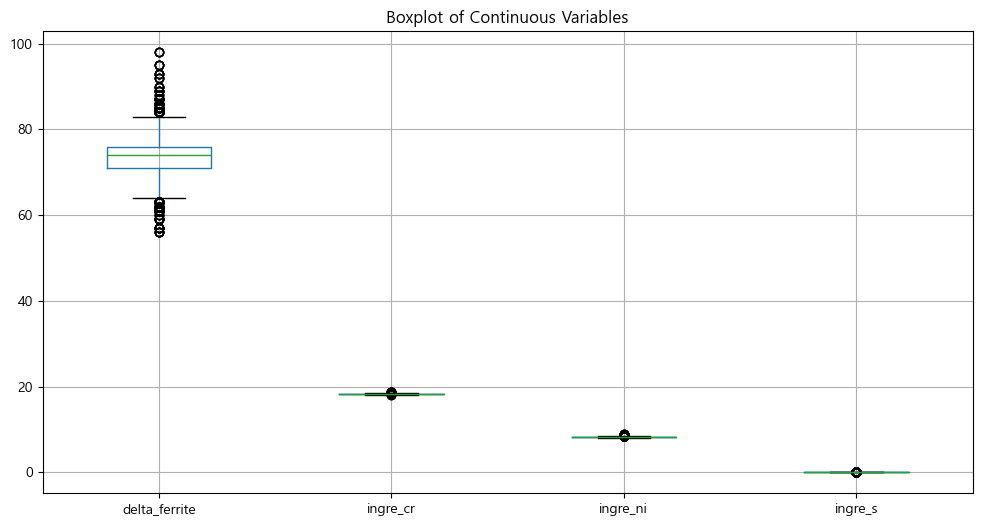

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

# 연속형 변수만 선택
cols = ['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s']

plt.figure(figsize=(12,6))
df_1[cols].boxplot()
plt.title('Boxplot of Continuous Variables')
plt.show()

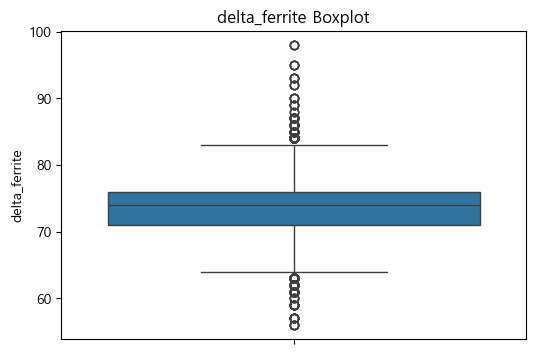

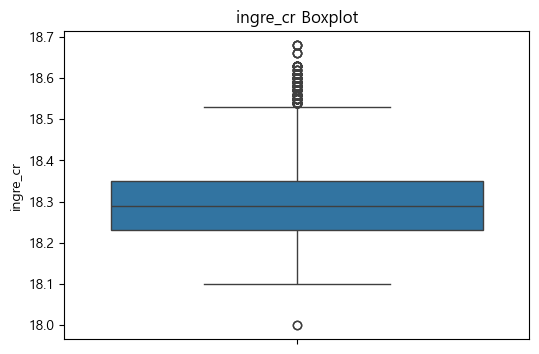

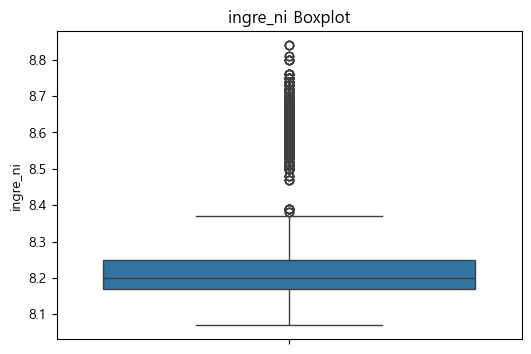

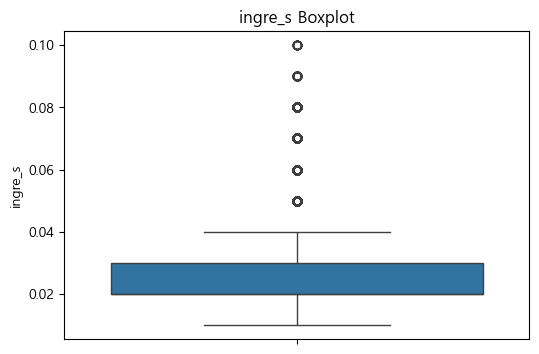

In [167]:
cols = ['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df_1[col])
    plt.title(f'{col} Boxplot')
    plt.show()

In [168]:
from scipy import stats
import numpy as np

cols = ['delta_ferrite','ingre_cr','ingre_ni','ingre_s']

z_scores = np.abs(stats.zscore(df_1[cols]))

# threshold = 3 (보통 기준)
outliers = (z_scores > 3)

df_1[outliers.any(axis=1)]

,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
5,1공장,CH80154,C13,RZ1,68,18.40,8.22,0.08,2025-07-13,4연주,1478.0,95.9,411,C,MISS
6,1공장,CH80154,C13,RZ1,68,18.40,8.22,0.08,2025-07-13,4연주,1478.0,95.9,511,C,MISS
41,1공장,CH80168,C13,RJ1,74,18.29,8.23,0.07,2025-07-14,1연주,1486.0,94.8,511,C,HSHS
67,1공장,CH80278,C12,Other,61,18.29,8.64,0.04,2025-05-18,2연주,1492.0,93.5,211,C,MISS
68,1공장,CH80278,C12,RJ1,61,18.29,8.64,0.04,2025-06-18,1연주,1492.0,93.5,311,C,MISS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23505,2공장,CH49113,C13,Other,75,18.23,8.22,0.07,2025-07-12,2연주,1481.0,96.1,611,C,HSHS
23506,2공장,CH49113,C13,RJ1,75,18.23,8.22,0.07,2025-07-12,2연주,1481.0,96.1,111,C,HSHS
23514,2공장,CH49142,C13,RJ1,84,18.53,8.28,0.07,2025-07-13,4연주,1475.0,95.0,411,C,HSHS
23515,2공장,CH49142,C13,RJ1,84,18.53,8.28,0.07,2025-07-13,4연주,1475.0,95.0,511,C,HSHS


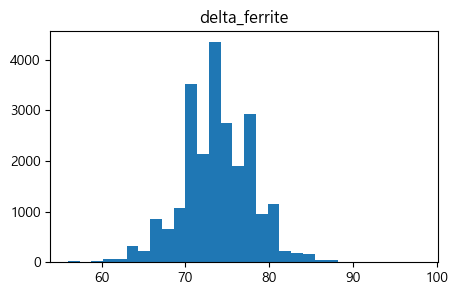

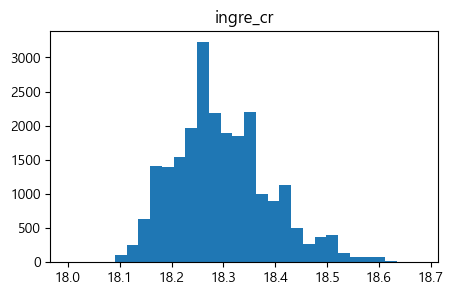

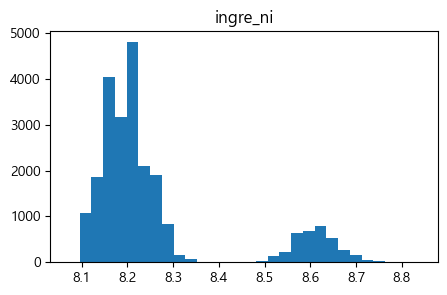

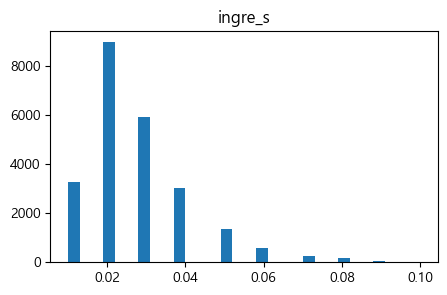

In [169]:
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(5,3))
    plt.hist(df_1[col], bins=30)
    plt.title(col)
    plt.show()

## 이상치 제거

In [170]:
print(df_1.columns)
print(df_2.columns)
print(df_3.columns)

print(len(df_2))


Index(['sm_plant', 'charge_id', 'steel_grade', 'steel_usage', 'delta_ferrite',
       'ingre_cr', 'ingre_ni', 'ingre_s', 'cast_date', 'cc_gubun',
       'tundish_temp', 'mlac_ratio', 'slab_no', 'slab_gubun', 'slab_grind'],
      dtype='object')
Index(['charge_id', 'slab_no', 'furnace_no', 'f_jangip_gubun', 'f_jangip_temp',
       'f_bfg', 'f_cog', 'f_ldg', 'f_bfg_per', 'f_cog_per', 'f_ldg_per',
       'f_pre_temp', 'f_heat_temp', 'f_sock_temp', 'f_pre_interval',
       'f_heat_interval', 'f_sock_interval', 'f_ext_date', 'f_ext_time',
       'hr_coil_id', 'hr_date', 'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
       'slab_width'],
      dtype='object')
Index(['judge', 'hr_coil_id', 'ap_plant', 'ap_prod_id', 'ap_date', 'ap_shift',
       'ap_thick', 'ap_width', 'ap_line_speed'],
      dtype='object')
23643


In [171]:
df_2= df_2[df_2['f_sock_temp']<1400]
df_2= df_2[df_2['f_sock_temp']>200]

<Axes: ylabel='f_sock_temp'>

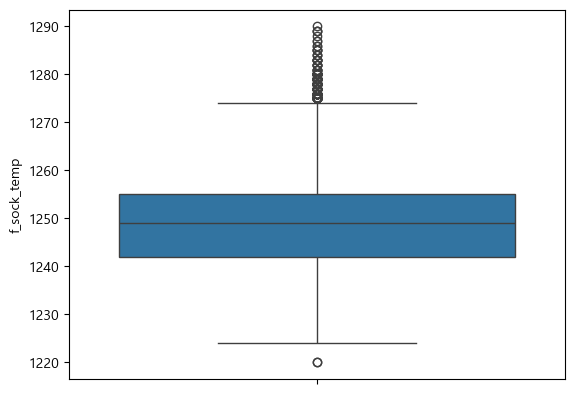

In [172]:
sns.boxplot(y=df_2['f_sock_temp'])

<Axes: ylabel='f_sock_interval'>

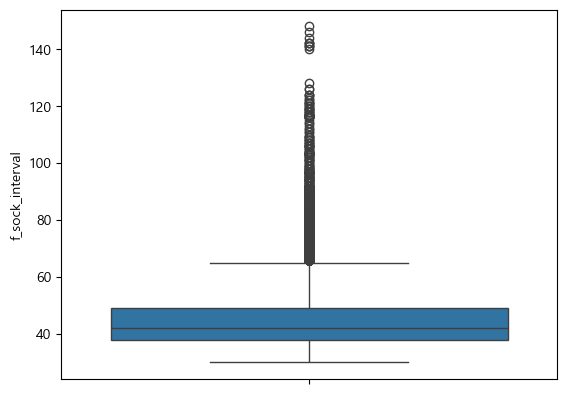

In [173]:
df_2= df_2[df_2['f_sock_interval']!=168]
sns.boxplot(y=df_2['f_sock_interval'])

In [174]:
df_2['hr_thick_group'] = np.select(
[
df_2['hr_thick'] <= 3.05,
(df_2['hr_thick'] >= 3.16) & (df_2['hr_thick'] <= 3.55),
(df_2['hr_thick'] >= 3.95) & (df_2['hr_thick'] <= 4.08),
df_2['hr_thick'] >= 4.94
],
[
'박재(<=3.05)',
'중박재(3.16~3.55)',
'중후재(3.95~4.08)',
'후재(>=4.94)'
],
default='기타'
)

In [175]:
print(len(df_2[df_2['hr_thick'] <= 3.05]))
print(len(df_2[(df_2['hr_thick'] >= 3.16) & (df_2['hr_thick'] <= 3.55)]))
print(len(df_2[(df_2['hr_thick'] >= 3.95) & (df_2['hr_thick'] <= 4.08)]))
print(len(df_2[df_2['hr_thick'] >= 4.94]))

12997
5442
2769
2428


In [176]:
len(df_2)

23640

In [177]:
# cast_date: 2월 데이터 제거
display(df_1.head())
print(df_1.info())


,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
0,1공장,CH80081,C12,RZ1,69,18.24,8.63,0.02,2025-05-09,2연주,1485.0,95.1,611,C,MISS
1,1공장,CH80092,C13,RZ1,70,18.45,8.34,0.03,2025-07-10,2연주,1496.0,100.0,511,M,MISS
2,1공장,CH80126,C13,RJ1,65,18.12,8.17,0.04,2025-07-12,1연주,1483.0,96.7,411,C,MISS
3,1공장,CH80126,C13,RZ1,65,18.12,8.17,0.04,2025-07-12,2연주,1483.0,96.7,311,C,MISS
4,1공장,CH80141,C13,RJ1,70,18.23,8.27,0.03,2025-07-12,2연주,1478.0,91.9,611,C,MISS


<class 'pandas.core.frame.DataFrame'>
Index: 23638 entries, 0 to 23648
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sm_plant       23638 non-null  object 
 1   charge_id      23638 non-null  object 
 2   steel_grade    23638 non-null  object 
 3   steel_usage    23638 non-null  object 
 4   delta_ferrite  23638 non-null  int64  
 5   ingre_cr       23638 non-null  float64
 6   ingre_ni       23638 non-null  float64
 7   ingre_s        23638 non-null  float64
 8   cast_date      23638 non-null  object 
 9   cc_gubun       23638 non-null  object 
 10  tundish_temp   23638 non-null  float64
 11  mlac_ratio     23638 non-null  float64
 12  slab_no        23638 non-null  int64  
 13  slab_gubun     23638 non-null  object 
 14  slab_grind     23638 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 2.9+ MB
None


In [178]:
df_1['cast_date']= pd.to_datetime(df_1['cast_date'], format= '%Y-%m-%d')
df_1= df_1[df_1['cast_date'].dt.month != 2]

In [179]:
cond = (
((df_2['f_bfg'] > 0) & (df_2['f_bfg_per'] == 0)) |
((df_2['f_cog'] > 0) & (df_2['f_cog_per'] == 0))
)

df_2 = df_2[~cond].copy()

## 데이터 병합

In [180]:
#df_1 에서 charge_id 랑 slab_no 를 묶어 중복값 확인
duplicates_df_sts1 = df_1[df_1.duplicated(subset=['charge_id', 'slab_no'], keep=False)]
# 결과 확인
print("--- df1의 중복 키 행 ---")
print(duplicates_df_sts1.sort_values(by=['charge_id', 'slab_no']))

--- df1의 중복 키 행 ---
Empty DataFrame
Columns: [sm_plant, charge_id, steel_grade, steel_usage, delta_ferrite, ingre_cr, ingre_ni, ingre_s, cast_date, cc_gubun, tundish_temp, mlac_ratio, slab_no, slab_gubun, slab_grind]
Index: []


In [181]:
duplicates_df_sts2 = df_2[df_2.duplicated(subset=['charge_id', 'slab_no'], keep=False)]
# 결과 확인
print("--- df2의 중복 키 행 ---")
print(duplicates_df_sts2.sort_values(by=['charge_id', 'slab_no']))

--- df2의 중복 키 행 ---
  charge_id  slab_no furnace_no f_jangip_gubun  f_jangip_temp  f_bfg   f_cog  \
3   CH42171      511        1호기            CCR             30  24.37  35.202   
4   CH42171      511        4호기            CCR             30  24.37  35.202   

   f_ldg  f_bfg_per  f_cog_per  ...  f_ext_date  f_ext_time  hr_coil_id  \
3    0.0   40.90848   59.09152  ...  2025-08-07          17     U700364   
4    0.0   40.90848   59.09152  ...  2025-08-07          17     U700364   

      hr_date  hr_thick  hr_width  rm4_temp rm_pitch  slab_width  \
3  2025-08-07      3.04      1248      1116       91        1240   
4  2025-08-07      3.04      1248      1116       91        1240   

  hr_thick_group  
3     박재(<=3.05)  
4     박재(<=3.05)  

[2 rows x 27 columns]


In [182]:
index_to_remove = [3,4] # 3,4 번은 furnace_no 이외의 모든값이 동일 하므로 판단불가 및 2개 제품 모두 양품
df2_cleaned = df_2.drop(index_to_remove)
df_2 = df2_cleaned.reset_index(drop=True)

In [183]:
print("--- df2의 중복 키 행 ---")

print(df_2.sort_values(by=['charge_id', 'slab_no']))

--- df2의 중복 키 행 ---
      charge_id  slab_no furnace_no f_jangip_gubun  f_jangip_temp   f_bfg  \
0       CH42126      511        4호기            CCR             30  23.750   
1       CH42126      611        1호기            CCR             30  23.750   
2       CH42157      511        3호기            CCR             30  24.370   
3       CH42193      411        3호기            CCR             30  26.308   
4       CH42207      611        4호기            CCR             30  23.666   
...         ...      ...        ...            ...            ...     ...   
23631   CH87509      511        3호기            HCR            420  18.985   
23632   CH87510      111        2호기            HCR            412  18.985   
23633   CH87510      211        1호기            HCR            398  18.985   
23634   CH87510      311        1호기            CCR            140  22.517   
23635   CH87516      511        1호기            HCR            499  23.257   

        f_cog  f_ldg  f_bfg_per  f_cog_per  ...  f_ext_

In [184]:
merged_df = pd.merge(df_1, df_2, on=['charge_id', 'slab_no'], how='inner')

# 3. 2단계 병합: 열연(HR)과 소둔산세(AP) 연결
# hr_coil_id를 기준으로 최종 결과 매칭
final_df = pd.merge(merged_df, df_3, on='hr_coil_id', how='inner')

# 4. 결과 확인
print(f"최종 병합 데이터 형태: {final_df.shape}")
final_df.head()

최종 병합 데이터 형태: (23632, 48)


,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,...,slab_width,hr_thick_group,judge,ap_plant,ap_prod_id,ap_date,ap_shift,ap_thick,ap_width,ap_line_speed
0,1공장,CH80081,C12,RZ1,69,18.24,8.63,0.02,2025-05-09,2연주,...,1020,박재(<=3.05),양품,2공장,X91819,2025-08-10,A,2.93,1003.0,47.00
1,1공장,CH80092,C13,RZ1,70,18.45,8.34,0.03,2025-07-10,2연주,...,1240,박재(<=3.05),불량,1공장,A16946,2025-08-30,B,2.89,1257.0,43.30
2,1공장,CH80126,C13,RJ1,65,18.12,8.17,0.04,2025-07-12,1연주,...,1030,중박재(3.16~3.55),불량,2공장,Y77190,2025-08-11,B,3.41,1035.0,42.57
3,1공장,CH80126,C13,RZ1,65,18.12,8.17,0.04,2025-07-12,2연주,...,1030,후재(>=4.94),양품,2공장,Y77493,2025-08-17,A,4.97,1036.0,29.70
4,1공장,CH80141,C13,RJ1,70,18.23,8.27,0.03,2025-07-12,2연주,...,1020,후재(>=4.94),양품,1공장,A15211,2025-08-07,D,4.88,1037.0,31.00


In [185]:
#데이터값 오류에 대한 정정 코드 (교수님 문의 완료)
final_df["delta_ferrite"] = final_df["delta_ferrite"].astype(float) * 0.1

In [186]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23632 entries, 0 to 23631
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sm_plant         23632 non-null  object        
 1   charge_id        23632 non-null  object        
 2   steel_grade      23632 non-null  object        
 3   steel_usage      23632 non-null  object        
 4   delta_ferrite    23632 non-null  float64       
 5   ingre_cr         23632 non-null  float64       
 6   ingre_ni         23632 non-null  float64       
 7   ingre_s          23632 non-null  float64       
 8   cast_date        23632 non-null  datetime64[ns]
 9   cc_gubun         23632 non-null  object        
 10  tundish_temp     23632 non-null  float64       
 11  mlac_ratio       23632 non-null  float64       
 12  slab_no          23632 non-null  int64         
 13  slab_gubun       23632 non-null  object        
 14  slab_grind       23632 non-null  objec

In [187]:
# 김성준 제강 공정 1번부터 8번까지 EDA
# sm_plant과 judge 간의 교차표 생성
pd.crosstab(final_df['sm_plant'], final_df['judge']) #일단 개수 시각화하기 

judge,불량,양품
sm_plant,,
1공장,220,11058
2공장,409,11945


In [188]:
pd.crosstab(final_df['sm_plant'], final_df['judge'], margins=True, margins_name='Total')

judge,불량,양품,Total
sm_plant,,,
1공장,220,11058,11278
2공장,409,11945,12354
Total,629,23003,23632


In [189]:
pd.crosstab(final_df['sm_plant'], final_df['judge'], normalize='index')

judge,불량,양품
sm_plant,,
1공장,0.019507,0.980493
2공장,0.033107,0.966893


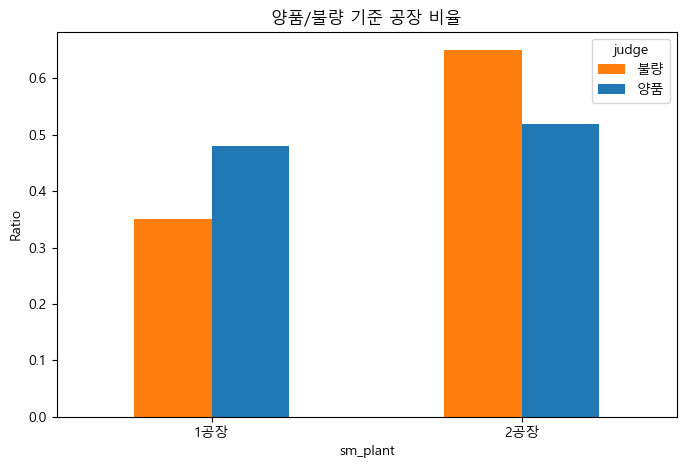

In [190]:
ratio = pd.crosstab(final_df['sm_plant'], final_df['judge'], normalize='columns')
import matplotlib.pyplot as plt

ratio.plot(kind='bar', figsize=(8,5),color={'양품': '#1f77b4', '불량': '#ff7f0e'})

plt.title('양품/불량 기준 공장 비율')
plt.ylabel('Ratio')
plt.xlabel('sm_plant')
plt.xticks(rotation=0)

plt.show()

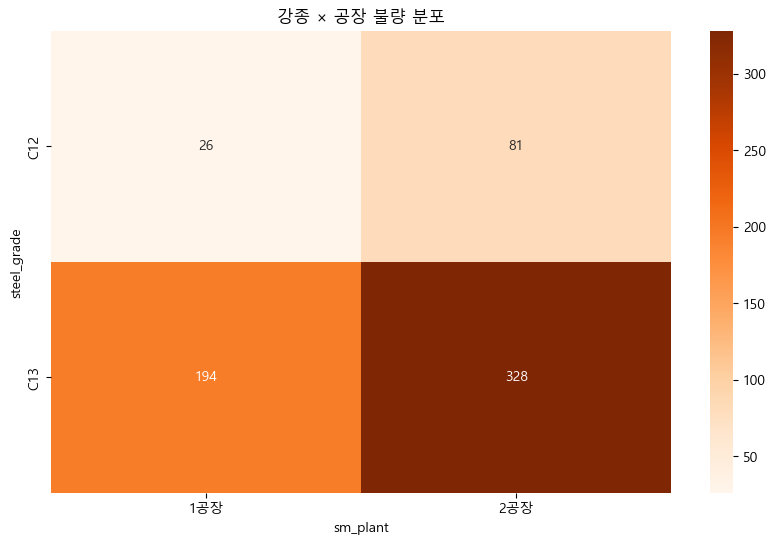

In [191]:
df_bad = final_df[final_df['judge'] == '불량']

pivot = pd.crosstab(df_bad['steel_grade'], df_bad['sm_plant'])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Oranges')

plt.title('강종 × 공장 불량 분포')
plt.xlabel('sm_plant')
plt.ylabel('steel_grade')

plt.show()

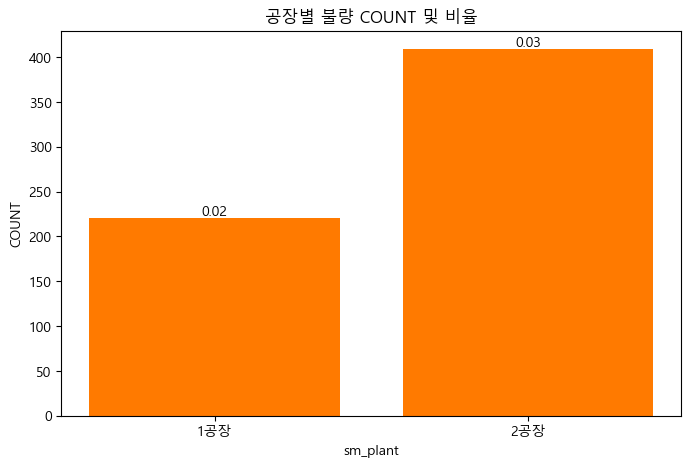

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. COUNT (불량 개수)
count = pd.crosstab(final_df['sm_plant'], final_df['judge'])
bad_count = count['불량']

# 2. RATIO (불량 비율)
ratio = pd.crosstab(final_df['sm_plant'], final_df['judge'], normalize='index')
bad_ratio = ratio['불량']

# 3. 그래프
plt.figure(figsize=(8,5))
bars = plt.bar(bad_count.index, bad_count.values,  color='#FF7A00' )

# 4. 비율 텍스트 추가
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bad_ratio.iloc[i]:.2f}",   # 비율 표시
        ha='center',
        va='bottom'
    )

plt.title('공장별 불량 COUNT 및 비율')
plt.ylabel('COUNT')
plt.xlabel('sm_plant')
plt.xticks(rotation=0)

plt.show()

In [193]:
# Y값 Ratio는 전체 불품 중에서 1,2공장에서 나온 불품 개수
# 2공정의 불품률이 더 크다.


In [194]:
#이제는 steel_grade와 judge 간의 교차표 생성
table = pd.crosstab(final_df['steel_grade'], final_df['judge'])
table

judge,불량,양품
steel_grade,,
C12,107,3466
C13,522,19537


In [195]:
table['defect_rate'] = table['불량'] / (table['양품'] + table['불량'])
table

judge,불량,양품,defect_rate
steel_grade,,,
C12,107,3466,0.029947
C13,522,19537,0.026023


In [196]:
pd.crosstab(final_df['steel_grade'], final_df['judge'], normalize='index')

judge,불량,양품
steel_grade,,
C12,0.029947,0.970053
C13,0.026023,0.973977


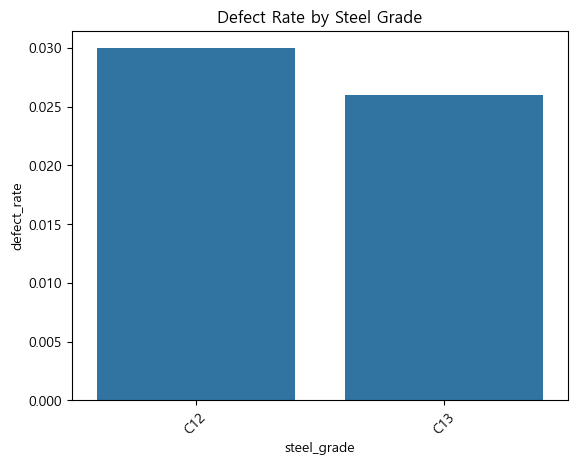

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

top_grade = table.sort_values('defect_rate', ascending=False).head(10)

sns.barplot(x=top_grade.index, y=top_grade['defect_rate'])
plt.xticks(rotation=45)
plt.title('Defect Rate by Steel Grade')
plt.show()

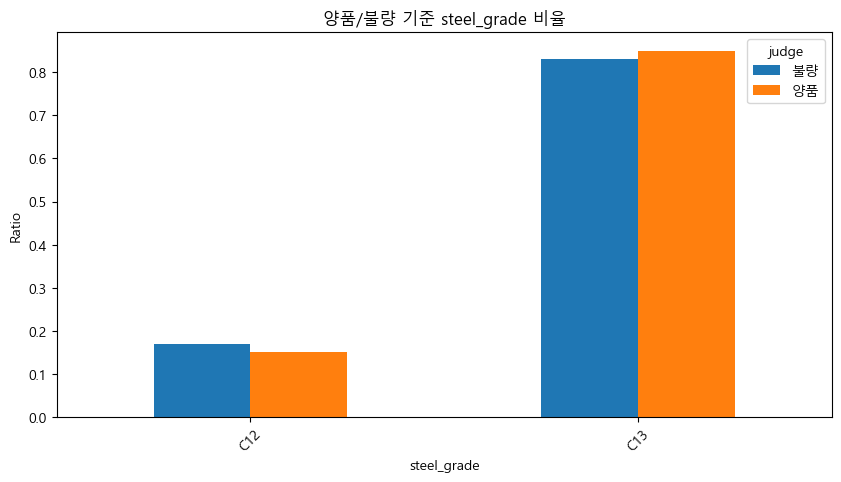

In [198]:
import pandas as pd
import matplotlib.pyplot as plt

# columns 기준 normalize (너가 쓰던 방식 그대로)
ratio = pd.crosstab(final_df['steel_grade'], final_df['judge'], normalize='columns')

# 그래프
ratio.plot(kind='bar', figsize=(10,5))

plt.title('양품/불량 기준 steel_grade 비율')
plt.ylabel('Ratio')
plt.xlabel('steel_grade')
plt.xticks(rotation=45)

plt.show()
# 별 의미 없음 여긴

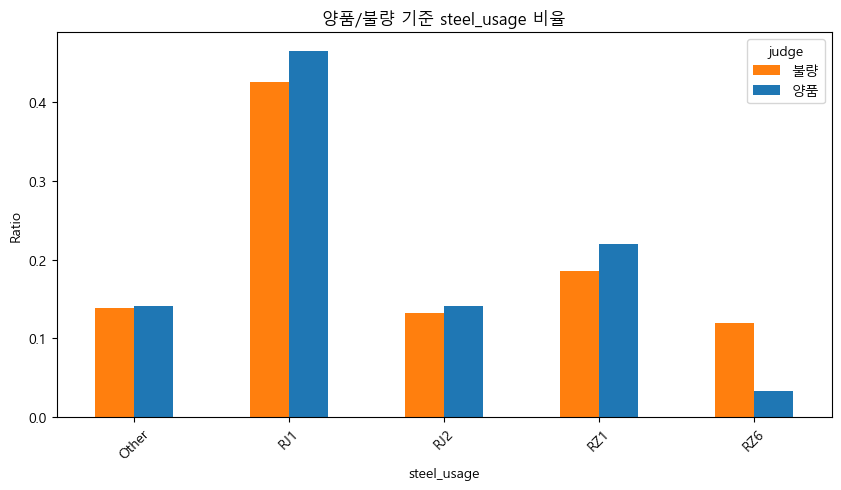

In [199]:
ratio = pd.crosstab(final_df['steel_usage'], final_df['judge'], normalize='columns')
import matplotlib.pyplot as plt

ratio.plot(kind='bar', figsize=(10,5), color={'양품': '#1f77b4', '불량': '#ff7f0e'})

plt.title('양품/불량 기준 steel_usage 비율')
plt.ylabel('Ratio')
plt.xlabel('steel_usage')
plt.xticks(rotation=45)

plt.show()

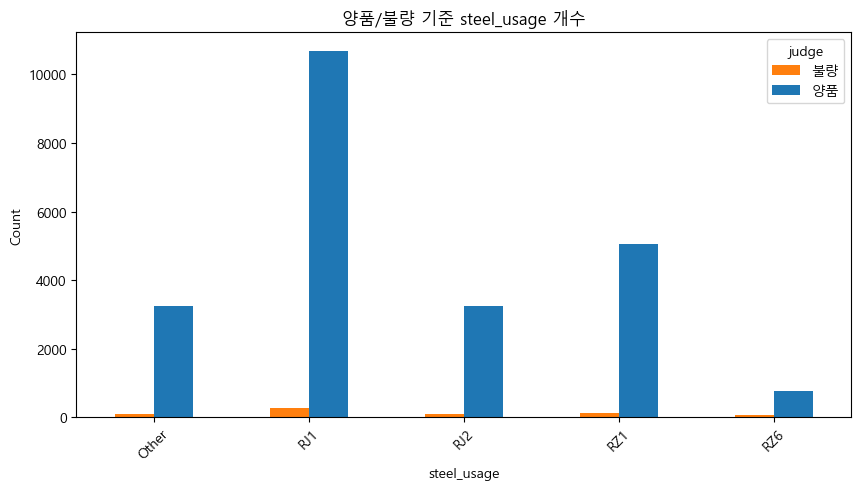

In [200]:
ratio = pd.crosstab(final_df['steel_usage'], final_df['judge'])  # normalize 제거

ratio.plot(kind='bar', figsize=(10,5),
           color={'양품': '#1f77b4', '불량': '#ff7f0e'})

plt.title('양품/불량 기준 steel_usage 개수')
plt.ylabel('Count')
plt.xlabel('steel_usage')
plt.xticks(rotation=45)

plt.show()

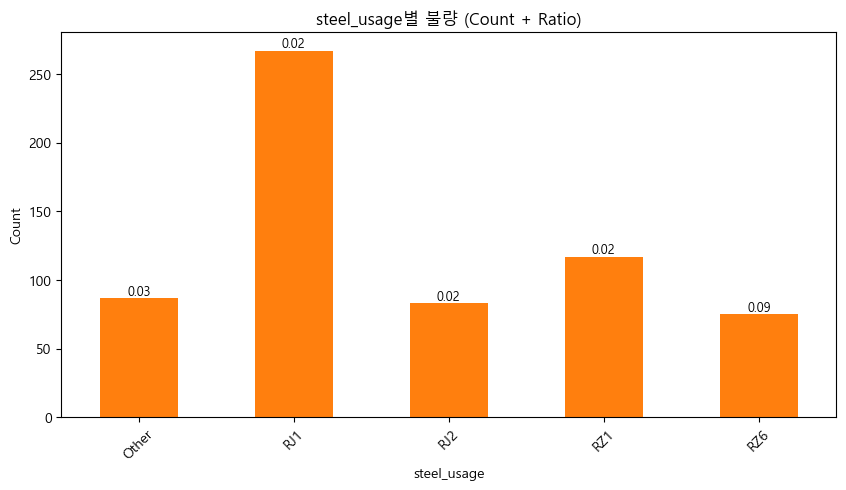

In [201]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. COUNT
count_df = pd.crosstab(final_df['steel_usage'], final_df['judge'])

# 2. RATIO (불량 비율)
ratio_df = pd.crosstab(final_df['steel_usage'], final_df['judge'], normalize='index')

# 불량만 사용
defect_count = count_df['불량']
defect_ratio = ratio_df['불량']

# 3. 그래프
ax = defect_count.plot(kind='bar', figsize=(10,5), color='#ff7f0e')

# 4. 위에 RATIO 표시
for i, p in enumerate(ax.patches):
    ax.annotate(f'{defect_ratio.iloc[i]:.2f}',   # 비율 표시
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('steel_usage별 불량 (Count + Ratio)')
plt.ylabel('Count')
plt.xlabel('steel_usage')
plt.xticks(rotation=45)

plt.show()

해석하면, RJ1이 일단 불량률이 제일 높음. 즉 불량률 중 RJ1 이 가장 높은 뜻
하지만 양품률도 높은 거 보니, 그냥 RJ1이 생산량이 많은듯
따라서 그닥 해석 가치는 없다고 판단된다. 
RZ6 개수만 보기

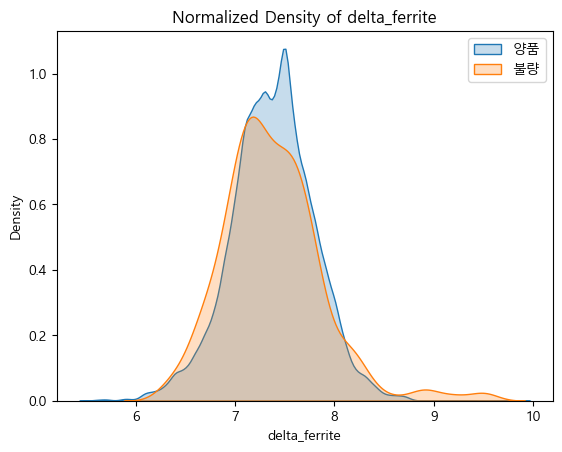

In [202]:
##델타_페라이트랑 juge관계 분석

sns.kdeplot(data=final_df[final_df['judge']=='양품'], 
            x='delta_ferrite', 
            label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'], 
            x='delta_ferrite', 
            label='불량', fill=True)

plt.title('Normalized Density of delta_ferrite')
plt.legend()
plt.show()

In [203]:
final_df['ferrite_bin'] = pd.cut(final_df['delta_ferrite'], bins=10)

In [204]:
bin_table = pd.crosstab(final_df['ferrite_bin'], final_df['judge'], normalize='index')

# 불량률만 추출
bin_table['defect_rate'] = bin_table['불량']

bin_table

judge,불량,양품,defect_rate
ferrite_bin,,,
"(5.596, 6.02]",0.000000,1.000000,0.000000
"(6.02, 6.44]",0.024609,0.975391,0.024609
"(6.44, 6.86]",0.034722,0.965278,0.034722
"(6.86, 7.28]",0.031106,0.968894,0.031106
"(7.28, 7.7]",0.022358,0.977642,0.022358
"(7.7, 8.12]",0.020742,0.979258,0.020742
"(8.12, 8.54]",0.042328,0.957672,0.042328
"(8.54, 8.96]",0.091954,0.908046,0.091954
"(8.96, 9.38]",0.285714,0.714286,0.285714


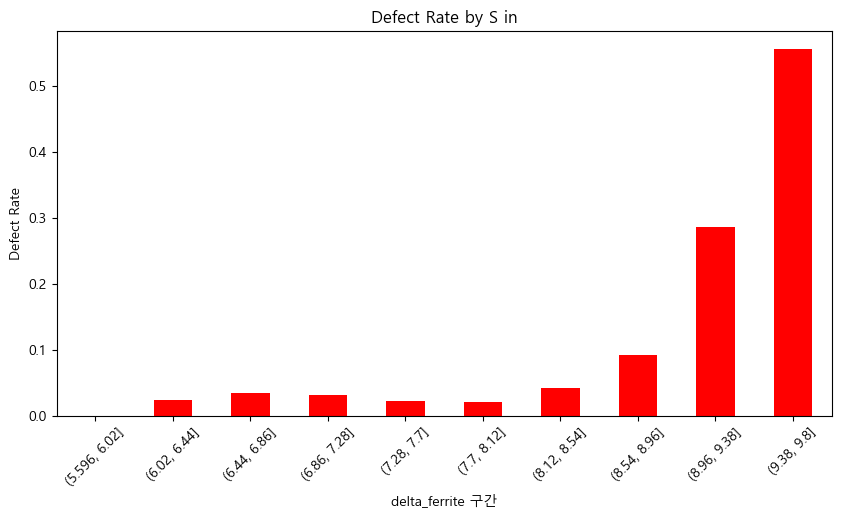

In [205]:
import matplotlib.pyplot as plt

bin_table['defect_rate'].plot(kind='bar', figsize=(10,5), color='red')

plt.title('Defect Rate by S in')
plt.ylabel('Defect Rate')
plt.xlabel('delta_ferrite 구간')
plt.xticks(rotation=45)

plt.show()

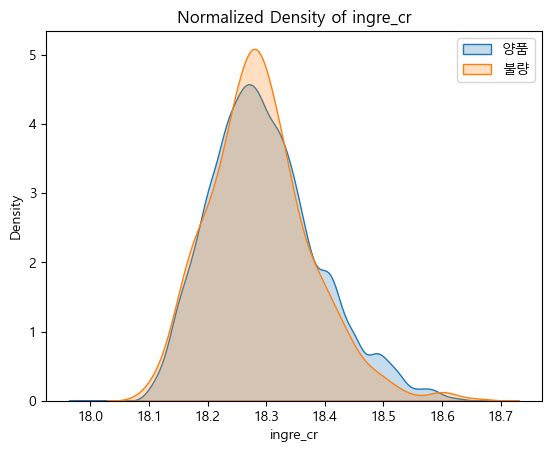

In [206]:
## ingre_cr과 judge 관계 분석

sns.kdeplot(data=final_df[final_df['judge']=='양품'], 
            x='ingre_cr', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'], 
            x='ingre_cr', label='불량', fill=True)

plt.title('Normalized Density of ingre_cr')
plt.legend()
plt.show()

judge,불량,양품,defect_rate
cr_bin,,,
"(17.999, 18.068]",0.000000,1.000000,0.000000
"(18.068, 18.136]",0.032967,0.967033,0.032967
"(18.136, 18.204]",0.027051,0.972949,0.027051
"(18.204, 18.272]",0.025523,0.974477,0.025523
"(18.272, 18.34]",0.031924,0.968076,0.031924
"(18.34, 18.408]",0.023284,0.976716,0.023284
"(18.408, 18.476]",0.020430,0.979570,0.020430
"(18.476, 18.544]",0.016741,0.983259,0.016741
"(18.544, 18.612]",0.022124,0.977876,0.022124


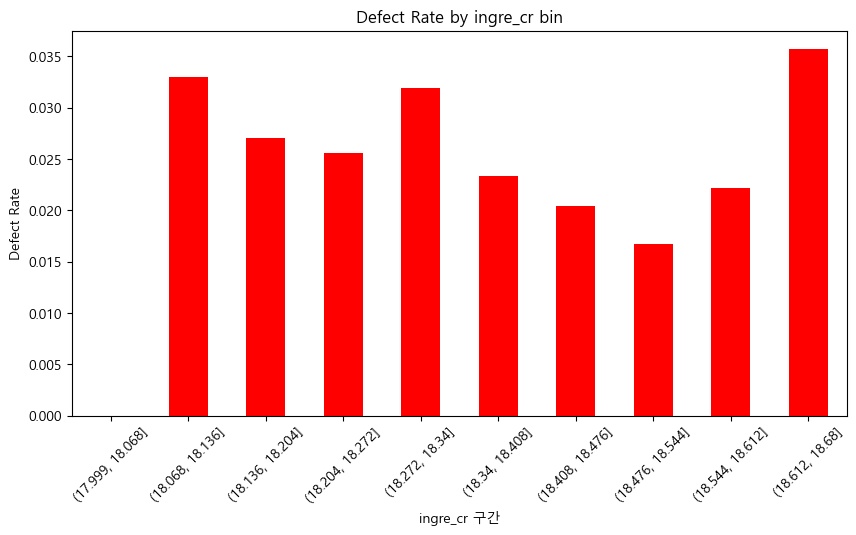

In [207]:
final_df['cr_bin'] = pd.cut(final_df['ingre_cr'], bins=10)
bin_table = pd.crosstab(final_df['cr_bin'], final_df['judge'], normalize='index')

bin_table['defect_rate'] = bin_table['불량']

bin_table['defect_rate'].plot(kind='bar', figsize=(10,5), color='red')

display(bin_table)


plt.title('Defect Rate by ingre_cr bin')
plt.ylabel('Defect Rate')
plt.xlabel('ingre_cr 구간')

plt.xticks(rotation=45)
plt.show()

In [208]:
##구간별 해석 의미 없음. 

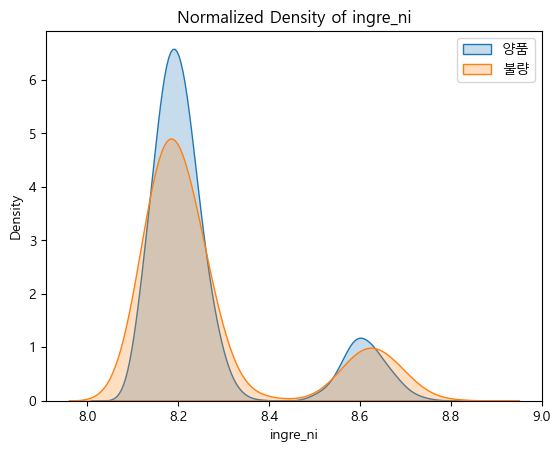

In [209]:
## ingre_ni와 judge해석


sns.kdeplot(data=final_df[final_df['judge']=='양품'], 
            x='ingre_ni', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'], 
            x='ingre_ni', label='불량', fill=True)

plt.title('Normalized Density of ingre_ni')
plt.legend()
plt.show()

judge,불량,양품,defect_rate
ni_bin,,,
"(8.069, 8.147]",0.030282,0.969718,0.030282
"(8.147, 8.224]",0.024996,0.975004,0.024996
"(8.224, 8.301]",0.026392,0.973608,0.026392
"(8.301, 8.378]",0.011952,0.988048,0.011952
"(8.378, 8.455]",0.200000,0.800000,0.200000
"(8.455, 8.532]",0.016575,0.983425,0.016575
"(8.532, 8.609]",0.020000,0.980000,0.020000
"(8.609, 8.686]",0.035176,0.964824,0.035176
"(8.686, 8.763]",0.062762,0.937238,0.062762


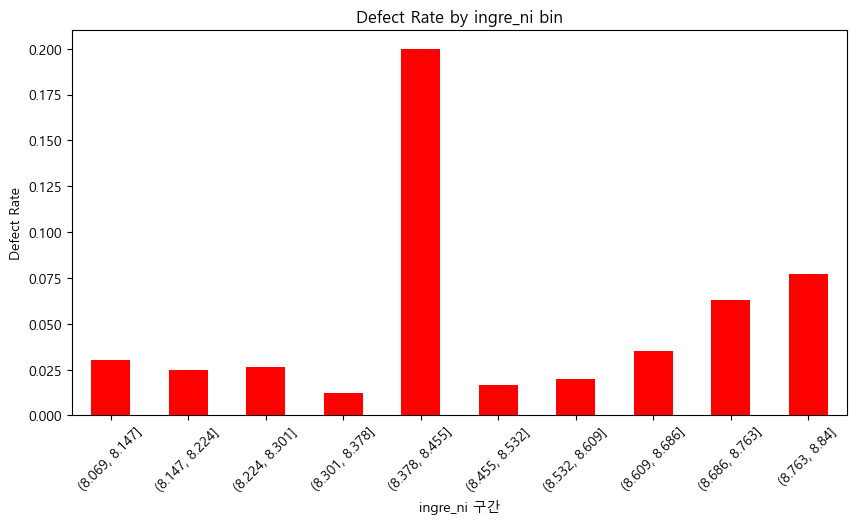

In [210]:
final_df['ni_bin'] = pd.cut(final_df['ingre_ni'], bins=10)
bin_table = pd.crosstab(final_df['ni_bin'], final_df['judge'], normalize='index')

bin_table['defect_rate'] = bin_table['불량']

display(bin_table)

bin_table['defect_rate'].plot(kind='bar', figsize=(10,5), color='red')

plt.title('Defect Rate by ingre_ni bin')
plt.ylabel('Defect Rate')
plt.xlabel('ingre_ni 구간')

plt.xticks(rotation=45)
plt.show()

In [211]:
## ?? 가운데가 높음. 뭐지

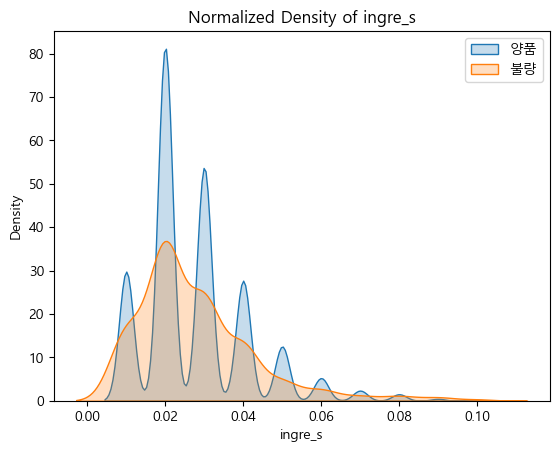

In [212]:


sns.kdeplot(data=final_df[final_df['judge']=='양품'], 
            x='ingre_s', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'], 
            x='ingre_s', label='불량', fill=True)

plt.title('Normalized Density of ingre_s')
plt.legend()
plt.show()

judge,불량,양품,defect_rate
s_bin,,,
"(0.00991, 0.019]",0.031326,0.968674,0.031326
"(0.019, 0.028]",0.025904,0.974096,0.025904
"(0.028, 0.037]",0.025051,0.974949,0.025051
"(0.037, 0.046]",0.026627,0.973373,0.026627
"(0.046, 0.055]",0.020468,0.979532,0.020468
"(0.055, 0.064]",0.027826,0.972174,0.027826
"(0.064, 0.073]",0.027237,0.972763,0.027237
"(0.073, 0.082]",0.041916,0.958084,0.041916
"(0.082, 0.091]",0.098039,0.901961,0.098039


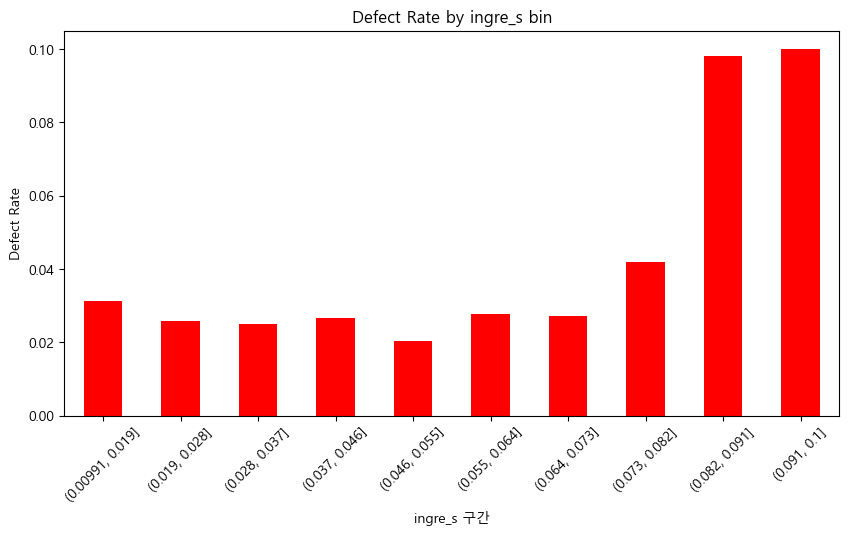

In [213]:
final_df['s_bin'] = pd.cut(final_df['ingre_s'], bins=10)
bin_table = pd.crosstab(final_df['s_bin'], final_df['judge'], normalize='index')

bin_table['defect_rate'] = bin_table['불량']

display(bin_table)
bin_table['defect_rate'].plot(kind='bar', figsize=(10,5), color='red')

plt.title('Defect Rate by ingre_s bin')
plt.ylabel('Defect Rate')
plt.xlabel('ingre_s 구간')

plt.xticks(rotation=45)
plt.show()

In [214]:
#이건 확실히 S함량이 높으면 결함율 증가 즉 0.082 넘으면 증가함. 
#따라서 뭔가 cr,ni,s 함량을 동시에 보기 위한 파생변수 (값)을 만들면 좋겠는데 (함량이니까)
#하지만 3개 변수 다 시각화 해본 결과 s함량이 가장 명확하게 결함율과 관계가 있어보임. 

In [215]:
final_df['composition_score'] = (
    0.2 * final_df['ingre_cr'] +
    0.3 * final_df['ingre_ni'] +
    0.5 * final_df['ingre_s']
)

#파생변수 설정.

In [216]:
final_df['comp_bin'] = pd.cut(final_df['composition_score'], bins=10)

In [217]:
bin_table = pd.crosstab(final_df['comp_bin'], final_df['judge'], normalize='index')
bin_table['defect_rate'] = bin_table['불량']

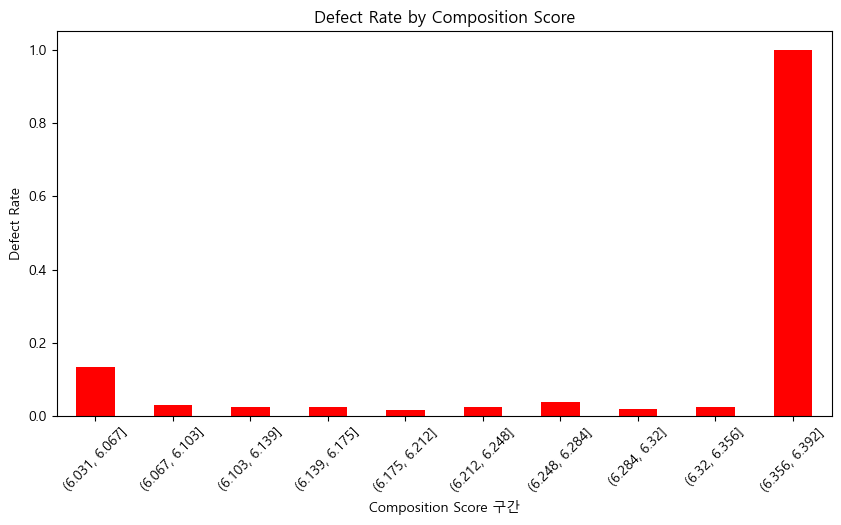

In [218]:
bin_table['defect_rate'].plot(kind='bar', figsize=(10,5), color='red')

import matplotlib.pyplot as plt
plt.title('Defect Rate by Composition Score')
plt.ylabel('Defect Rate')
plt.xlabel('Composition Score 구간')
plt.xticks(rotation=45)

plt.show()

In [219]:
# 3개 다 포함하는 파생변수를 만들고 싶음.
# Composition Score는 Cr(크롬), Ni(니켈), S(황) 세 가지 성분의 함량을 하나의 지표로 통합한 파생변수로, 
# 변수는 세 성분을 표준화한 후, 영향도의 크기에 따라 가중치 부여 Cr은 0.1 Ni는 0.3 S는 0.5 선형 결합 형태로 조성의 복합적인 특성을 하나의 수치로 표현한다. 
# 기존에는 개별 성분만으로 결함을 분석했을 때 명확한 패턴이 나타나지 않았으나, Composition Score를 활용함으로써 
# 성분 간 상호작용 효과를 반영할 수 있었고, 특정 값 이상에서 불량률이 급격히 증가하는 임계 구간을 확인할 수 있었다. 
# 따라서 Composition Score는 조성 조합에 따른 결함 발생 위험도를 나타내는 지표로 해석할 수 있다.

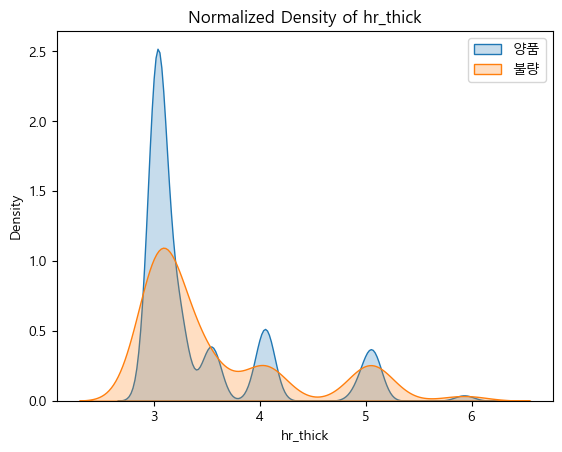

In [220]:
sns.kdeplot(data=final_df[final_df['judge']=='양품'], 
            x='hr_thick', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'], 
            x='hr_thick', label='불량', fill=True)

plt.title('Normalized Density of hr_thick')
plt.legend()
plt.show()

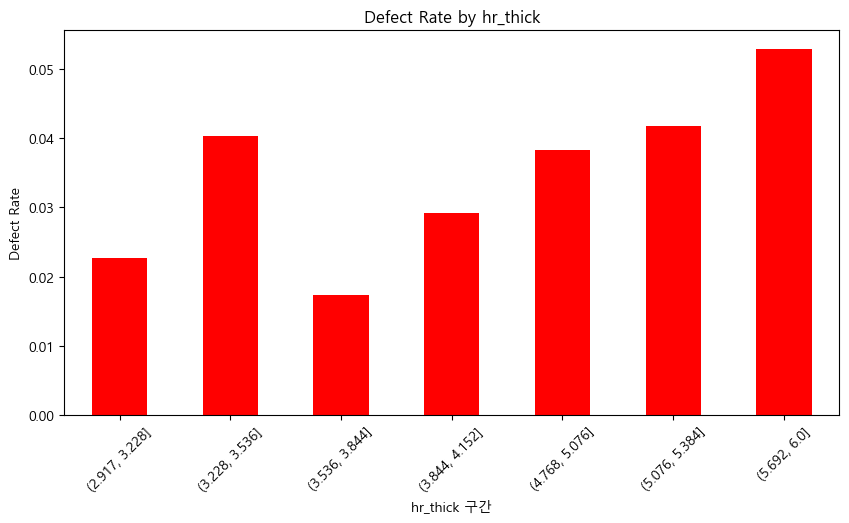

In [221]:
# 3. 구간화
# ================================
final_df['thick_bin'] = pd.cut(final_df['hr_thick'], bins=10)

# ================================
# 4. 구간별 결함률
# ================================
bin_table = pd.crosstab(final_df['thick_bin'], final_df['judge'], normalize='index')
bin_table['defect_rate'] = bin_table['불량']

# ================================
# 5. 그래프
# ================================
bin_table['defect_rate'].plot(kind='bar', figsize=(10,5), color='red')

plt.title('Defect Rate by hr_thick')
plt.ylabel('Defect Rate')
plt.xlabel('hr_thick 구간')

plt.xticks(rotation=45)
plt.show()

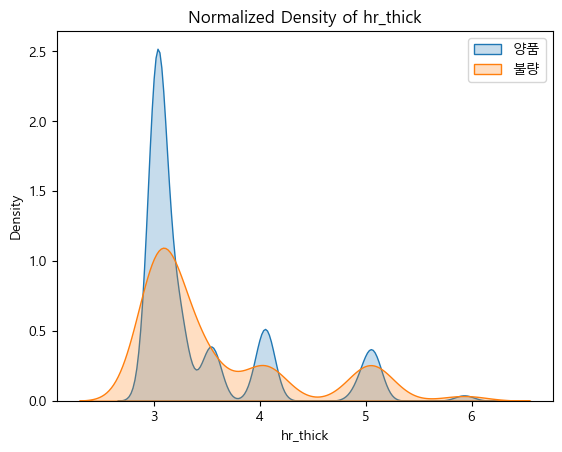

In [222]:
sns.kdeplot(data=final_df[final_df['judge']=='양품'], 
            x='hr_thick', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'], 
            x='hr_thick', label='불량', fill=True)

plt.title('Normalized Density of hr_thick')
plt.legend()
plt.show()

## 파생변수 형성   

In [223]:
# 파생변수
cols = [
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'hr_width', 'hr_thick'
]

final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce')



# 1. 총 재로시간
final_df['f_total_time'] = (
    final_df['f_pre_interval'] +
    final_df['f_heat_interval'] +
    final_df['f_sock_interval']
)


#2. 열간 압연 날짜 - 연주 날짜 
final_df['hr_date'] = pd.to_datetime(final_df['hr_date'], errors='coerce')
final_df['cast_date'] = pd.to_datetime(final_df['cast_date'], errors='coerce')

final_df['process_delay_time1'] = (
    final_df['hr_date'] - final_df['cast_date']
).dt.days


#3. 가열온도 - 예열온도
final_df['heat_pre_diff'] = final_df['f_heat_temp'] - final_df['f_pre_temp']

#4. 균열온도 - 압연온도
final_df['sock_rm4_diff'] = final_df['f_sock_temp'] - final_df['rm4_temp']




# 확인
final_df[
    [
        'f_total_time',
        'process_delay_time1',
        'heat_pre_diff',
        'sock_rm4_diff'
        
    ]

].head()

,f_total_time,process_delay_time1,heat_pre_diff,sock_rm4_diff
0,242.0,54,138.0,161.0
1,183.0,48,118.0,120.0
2,183.0,27,125.0,148.0
3,179.0,27,119.0,131.0
4,177.0,23,128.0,146.0


In [224]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23632 entries, 0 to 23631
Data columns (total 59 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   sm_plant             23632 non-null  object        
 1   charge_id            23632 non-null  object        
 2   steel_grade          23632 non-null  object        
 3   steel_usage          23632 non-null  object        
 4   delta_ferrite        23632 non-null  float64       
 5   ingre_cr             23632 non-null  float64       
 6   ingre_ni             23632 non-null  float64       
 7   ingre_s              23632 non-null  float64       
 8   cast_date            23632 non-null  datetime64[ns]
 9   cc_gubun             23632 non-null  object        
 10  tundish_temp         23632 non-null  float64       
 11  mlac_ratio           23632 non-null  float64       
 12  slab_no              23632 non-null  int64         
 13  slab_gubun           23632 non-

In [225]:
final_df.to_csv('final_파생변수진짜있는거.csv', index=False)

## t/f 검정

In [226]:
from scipy.stats import ttest_ind
import pandas as pd

# 1. 연속형 변수 자동 선택 (object 제외)
numeric_cols = final_df.select_dtypes(include=['float64', 'int64']).columns

results = []

for col in numeric_cols:
    try:
        good = final_df[final_df['judge']=='양품'][col].dropna()
        bad = final_df[final_df['judge']=='불량'][col].dropna()
        
        # Welch t-test (추천)
        t_stat, p_value = ttest_ind(good, bad, equal_var=False)
        
        results.append([col, t_stat, p_value])
        
    except:
        continue

# 결과 데이터프레임
result_df = pd.DataFrame(results, columns=['variable', 't_stat', 'p_value'])

# 정렬 (중요한 변수부터)
result_df = result_df.sort_values('p_value')

result_df

,variable,t_stat,p_value
7,f_jangip_temp,23.329277,9.092527e-89
31,process_delay_time1,-8.397716,2.886286e-16
19,f_sock_interval,-7.466456,2.652031e-13
30,f_total_time,-7.108062,3.175102e-12
14,f_pre_temp,-6.860464,1.583888e-11
32,heat_pre_diff,5.871754,6.872859e-09
28,ap_line_speed,5.721447,1.603416e-08
21,hr_thick,-4.582557,5.501564e-06
26,ap_thick,-4.504409,7.881871e-06
16,f_sock_temp,-4.176354,3.364261e-05


In [227]:
result_df[result_df['p_value'] < 0.05]

,variable,t_stat,p_value
7,f_jangip_temp,23.329277,9.092527e-89
31,process_delay_time1,-8.397716,2.886286e-16
19,f_sock_interval,-7.466456,2.652031e-13
30,f_total_time,-7.108062,3.175102e-12
14,f_pre_temp,-6.860464,1.583888e-11
32,heat_pre_diff,5.871754,6.872859e-09
28,ap_line_speed,5.721447,1.603416e-08
21,hr_thick,-4.582557,5.501564e-06
26,ap_thick,-4.504409,7.881871e-06
16,f_sock_temp,-4.176354,3.364261e-05


In [228]:
top5_vars = result_df.sort_values('p_value').head(5)

top5_vars

,variable,t_stat,p_value
7,f_jangip_temp,23.329277,9.092527e-89
31,process_delay_time1,-8.397716,2.886286e-16
19,f_sock_interval,-7.466456,2.652031e-13
30,f_total_time,-7.108062,3.175102e-12
14,f_pre_temp,-6.860464,1.583888e-11


In [229]:


# 1. 범주형 변수 자동 선택
categorical_cols = final_df.select_dtypes(include=['object']).columns

chi2_results = []

for col in categorical_cols:
    try:
        table = pd.crosstab(final_df[col], final_df['judge'])
        
        # 값이 너무 적은 경우 skip
        if table.shape[0] < 2:
            continue
        
        chi2, p, _, _ = chi2_contingency(table)
            
        chi2_results.append([col, chi2, p])
    except:
        continue

chi2_df = pd.DataFrame(chi2_results, columns=['variable', 'chi2', 'p_value'])

# 정렬
chi2_df = chi2_df.sort_values('p_value')

# TOP 5
top5_categorical = chi2_df.head(5)

print("\n=== 범주형 TOP5 변수 ===")
print(top5_categorical)


=== 범주형 TOP5 변수 ===
Empty DataFrame
Columns: [variable, chi2, p_value]
Index: []


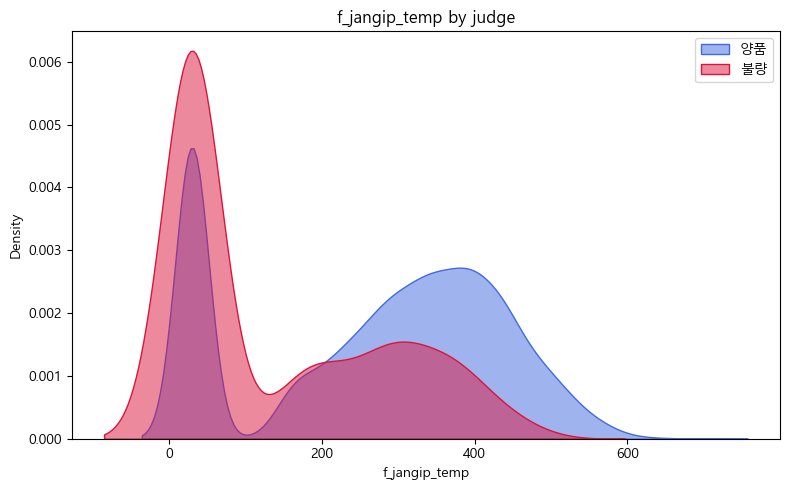

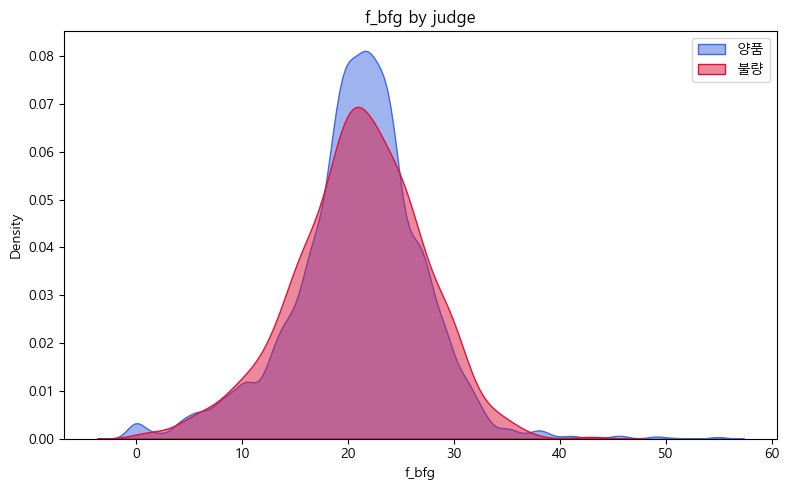

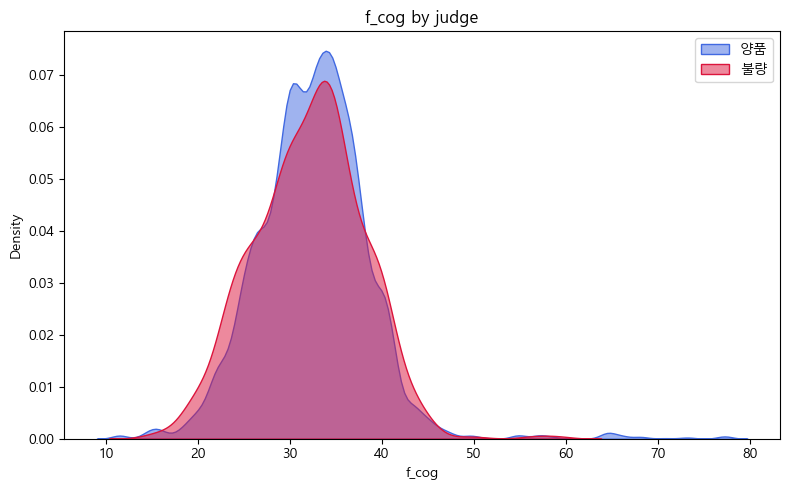

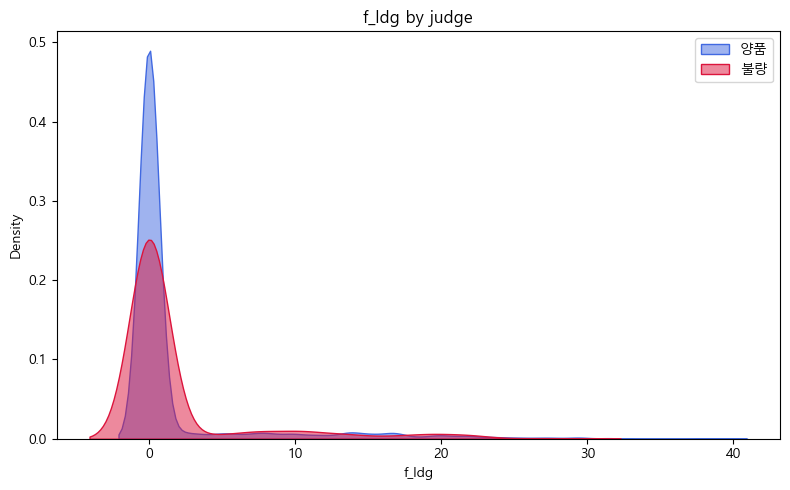

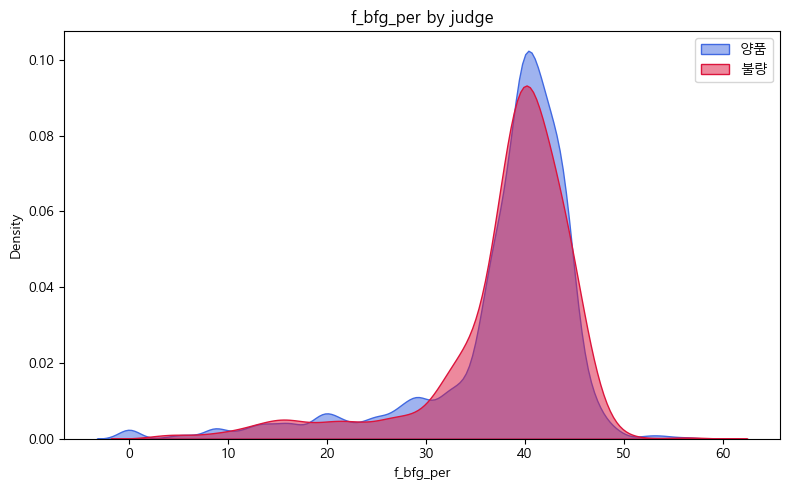

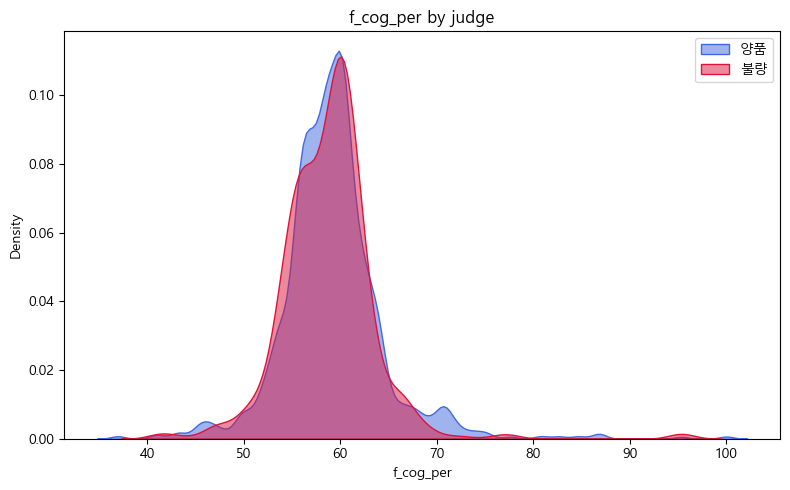

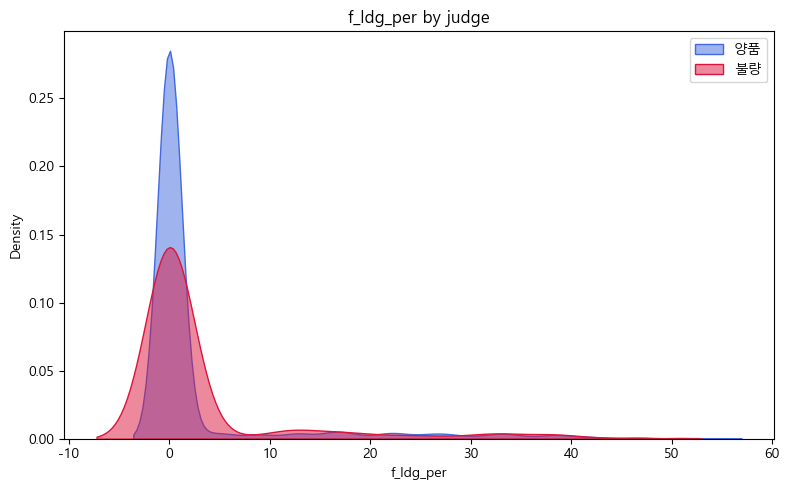

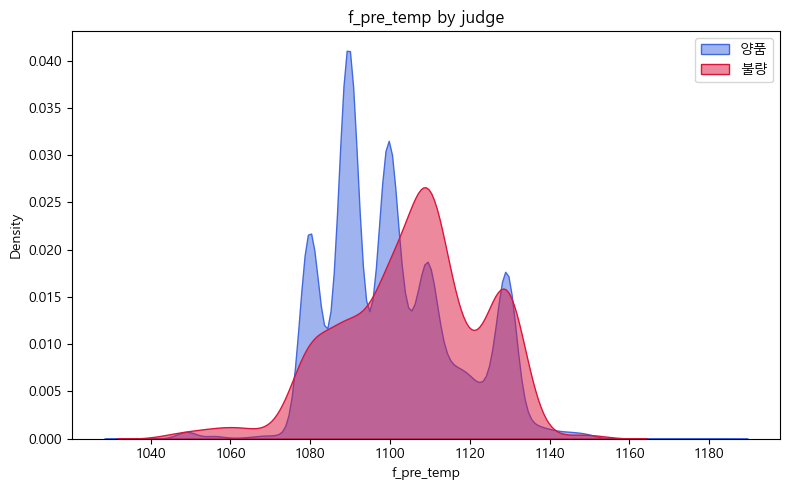

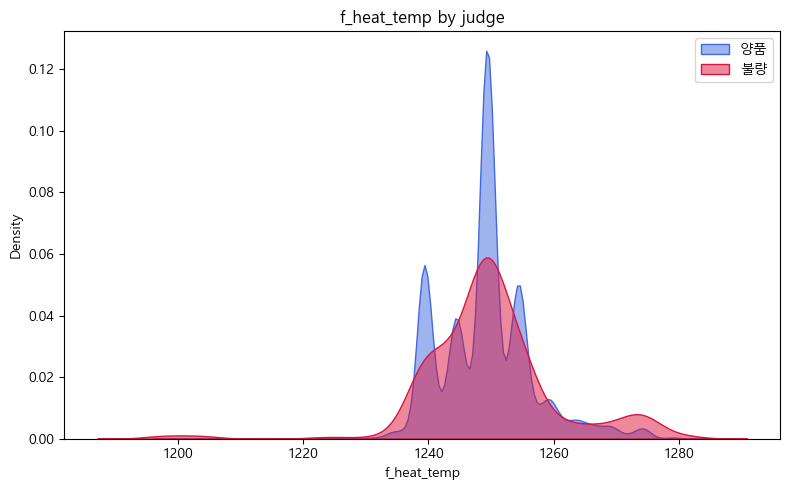

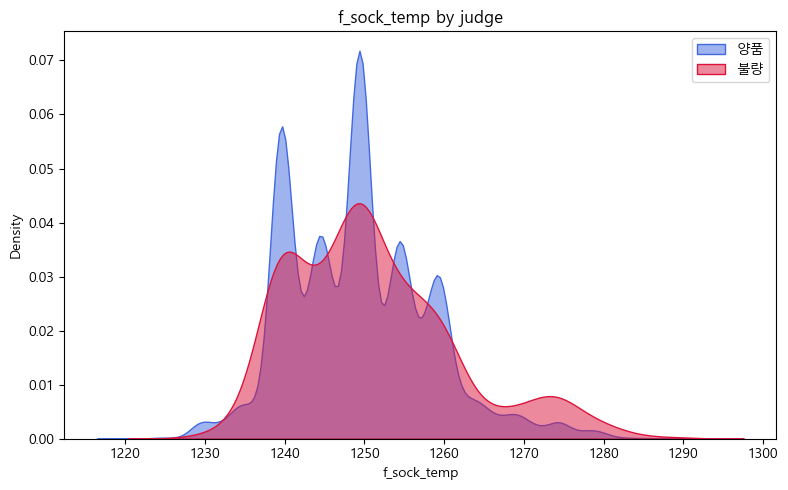

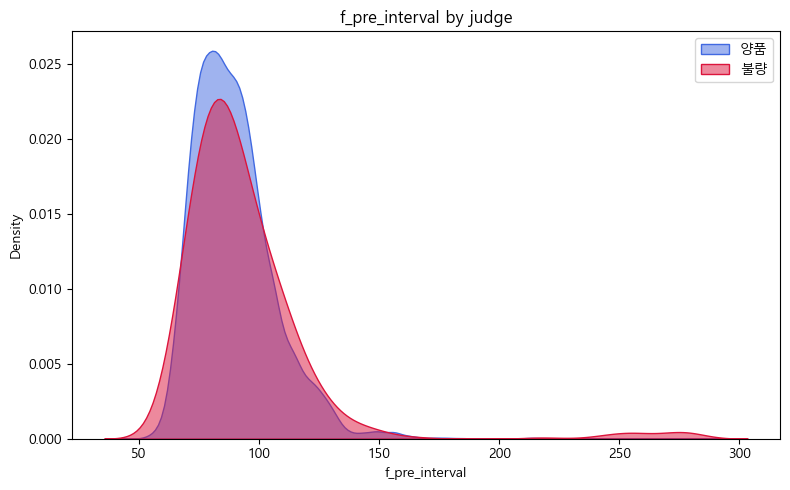

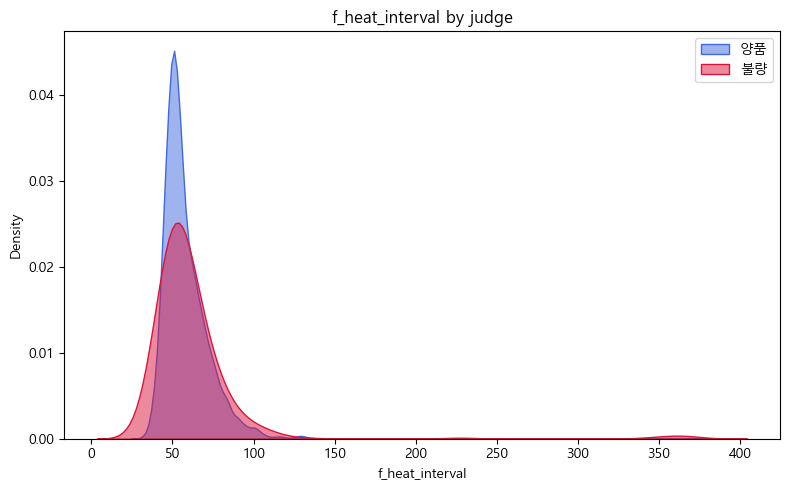

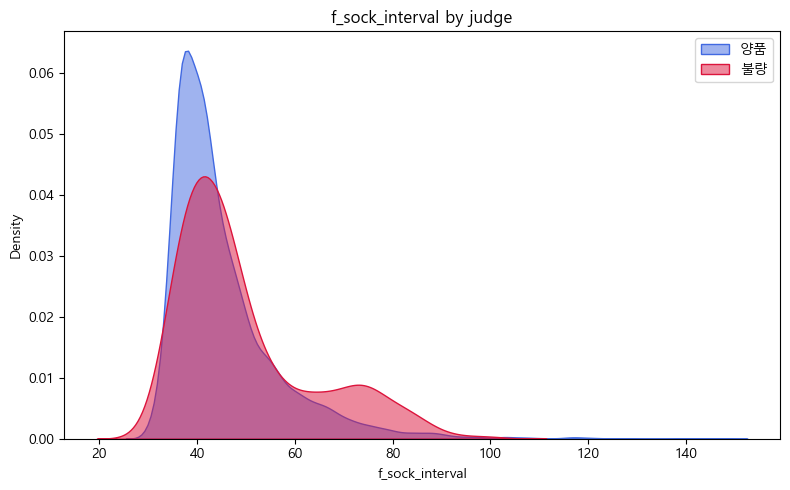

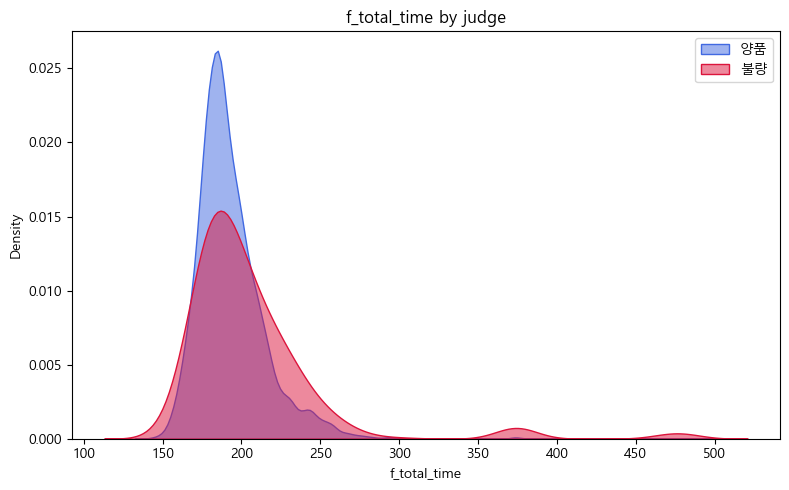

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = [
    'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
    'f_bfg_per', 'f_cog_per', 'f_ldg_per',
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'f_total_time'
]

for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=final_df[final_df['judge'] == '양품'],
        x=col,
        fill=True,
        common_norm=False,
        alpha=0.5,
        color='royalblue',
        label='양품'
    )

    sns.kdeplot(
        data=final_df[final_df['judge'] == '불량'],
        x=col,
        fill=True,
        common_norm=False,
        alpha=0.5,
        color='crimson',
        label='불량'
    )

    plt.title(f'{col} by judge')
    plt.legend()
    plt.tight_layout()
    plt.show()

## PPT제작하면서 한 추가적인 EDA

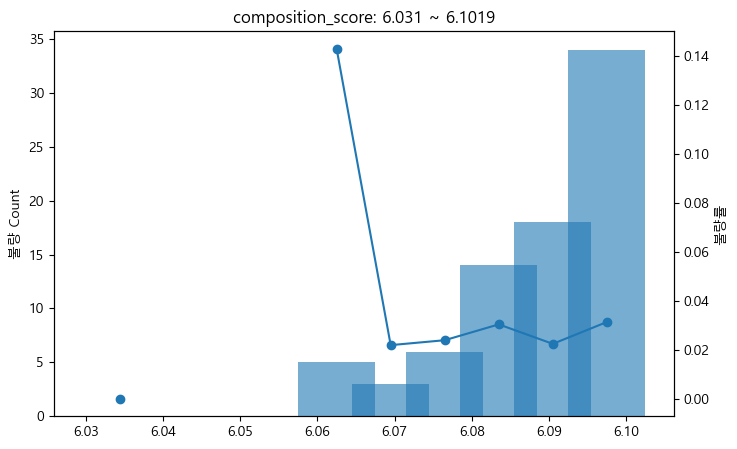

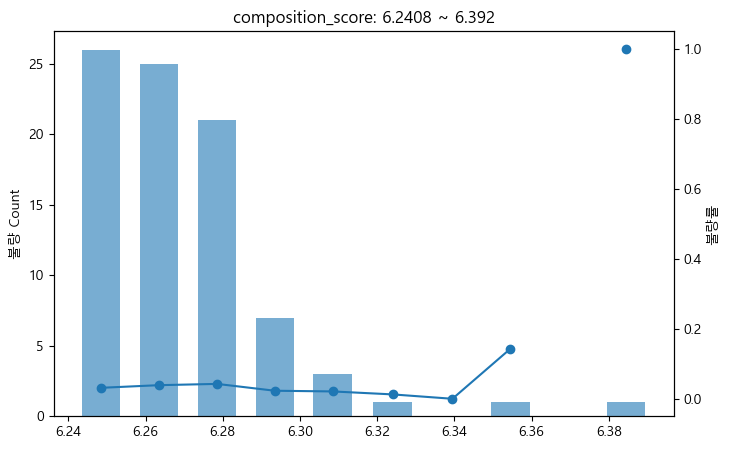

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 구간 정의
ranges = [
    (6.0310, 6.1019),
    (6.2408, 6.3920)
]

for low, high in ranges:
    
    df_range = final_df[
        (final_df['composition_score'] >= low) &
        (final_df['composition_score'] <= high)
    ].copy()

    # label 변환
    df_range['label'] = df_range['judge'].map({'양품': 0, '불량': 1})

    # bin (시각화용만)
    df_range['bin'] = pd.cut(df_range['composition_score'], bins=10)

    grouped = df_range.groupby('bin').agg(
        total=('label', 'count'),
        bad=('label', 'sum')
    )

    grouped['bad_ratio'] = grouped['bad'] / grouped['total']
    grouped['x'] = grouped.index.map(lambda x: x.mid)

    # -------------------
    # 그래프
    # -------------------
    fig, ax1 = plt.subplots(figsize=(8,5))

    # 막대 (불량 count)
    ax1.bar(grouped['x'], grouped['bad'], width=0.01, alpha=0.6)
    ax1.set_ylabel('불량 Count')

    # 선 (불량률)
    ax2 = ax1.twinx()
    ax2.plot(grouped['x'], grouped['bad_ratio'], marker='o')
    ax2.set_ylabel('불량률')

    plt.title(f'composition_score: {low} ~ {high}')
    plt.xlabel('composition_score')

    plt.show()

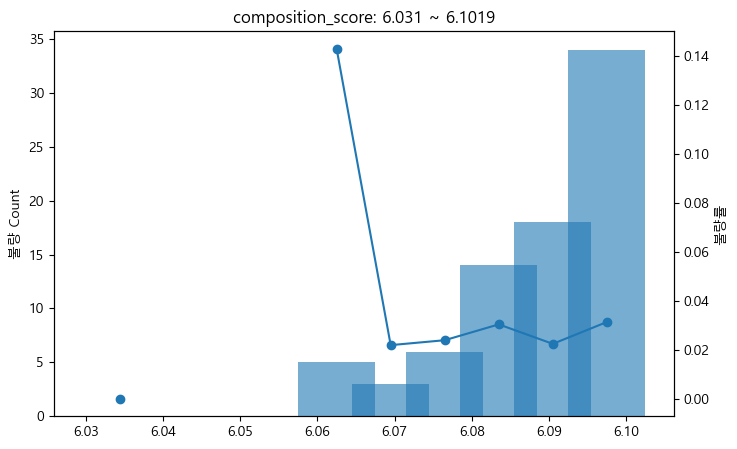

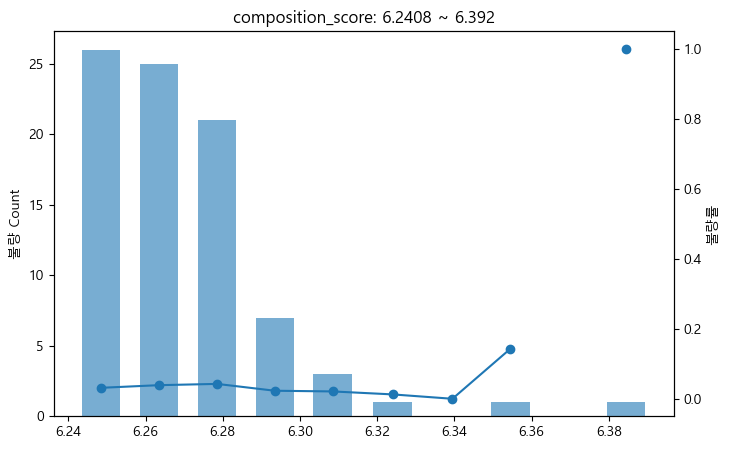

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 구간 정의
ranges = [
    (6.0310, 6.1019),
    (6.2408, 6.3920)
]

for low, high in ranges:
    
    df_range = final_df[
        (final_df['composition_score'] >= low) &
        (final_df['composition_score'] <= high)
    ].copy()

    # label 변환
    df_range['label'] = df_range['judge'].map({'양품': 0, '불량': 1})

    # bin (시각화용만)
    df_range['bin'] = pd.cut(df_range['composition_score'], bins=10)

    grouped = df_range.groupby('bin').agg(
        total=('label', 'count'),
        bad=('label', 'sum')
    )

    grouped['bad_ratio'] = grouped['bad'] / grouped['total']
    grouped['x'] = grouped.index.map(lambda x: x.mid)

    # -------------------
    # 그래프
    # -------------------
    fig, ax1 = plt.subplots(figsize=(8,5))

    # 막대 (불량 count)
    ax1.bar(grouped['x'], grouped['bad'], width=0.01, alpha=0.6)
    ax1.set_ylabel('불량 Count')

    # 선 (불량률)
    ax2 = ax1.twinx()
    ax2.plot(grouped['x'], grouped['bad_ratio'], marker='o')
    ax2.set_ylabel('불량률')

    plt.title(f'composition_score: {low} ~ {high}')
    plt.xlabel('composition_score')

    plt.show()

## 작업조와 다른 변수들간에 상관관계 분석

In [237]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_excel('final_df.xlsx')

# 연속형 변수만 선택
num_cols = df.select_dtypes(include=['int64','float64']).columns

results = []

for col in num_cols:
    groups = [group[col].dropna() for name, group in df.groupby('ap_shift')]
    
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        results.append((col, p_val))

# p-value 기준 정렬
anova_df = pd.DataFrame(results, columns=['variable', 'p_value'])
anova_df = anova_df.sort_values('p_value')

print(anova_df.head(30))

           variable       p_value
21         hr_thick  3.644393e-18
26         ap_thick  9.018652e-17
28    ap_line_speed  5.050932e-16
12        f_cog_per  7.405636e-16
8             f_bfg  6.974626e-12
22         hr_width  4.963693e-10
2          ingre_ni  6.304953e-10
25       slab_width  1.103967e-09
27         ap_width  5.047100e-09
17   f_pre_interval  1.663113e-08
5        mlac_ratio  9.922520e-08
14       f_pre_temp  1.310425e-07
11        f_bfg_per  8.288044e-07
23         rm4_temp  3.026997e-06
10            f_ldg  4.804607e-06
3           ingre_s  1.588914e-05
19  f_sock_interval  2.951210e-05
13        f_ldg_per  1.135028e-04
16      f_sock_temp  1.391625e-04
1          ingre_cr  1.312378e-03
9             f_cog  2.486818e-03
18  f_heat_interval  1.358564e-02
4      tundish_temp  1.879746e-02
20       f_ext_time  7.214178e-02
15      f_heat_temp  2.848322e-01
0     delta_ferrite  2.907313e-01
7     f_jangip_temp  3.413540e-01
6           slab_no  3.977979e-01
24         rm_

In [238]:
import pandas as pd
import numpy as np

df = pd.read_excel('final_df.xlsx')

num_cols = df.select_dtypes(include=['int64','float64']).columns

scores = []

for col in num_cols:
    # 전체 평균
    overall_mean = df[col].mean()
    
    # 그룹별 평균
    group_means = df.groupby('ap_shift')[col].mean()
    
    # 그룹간 분산 (between variance)
    between_var = np.var(group_means)
    
    # 전체 분산
    total_var = np.var(df[col])
    
    if total_var != 0:
        score = between_var / total_var
        scores.append((col, score))

score_df = pd.DataFrame(scores, columns=['variable','score'])
score_df = score_df.sort_values('score', ascending=False)

print(score_df.head(6))

         variable     score
21       hr_thick  0.003585
26       ap_thick  0.003313
28  ap_line_speed  0.003132
12      f_cog_per  0.003125
8           f_bfg  0.002320
2        ingre_ni  0.001953


In [239]:
cat_cols = df.select_dtypes(include='object').columns

cat_scores = []

for col in cat_cols:
    if col == 'ap_shift':
        continue
        
    ratio = pd.crosstab(df['ap_shift'], df[col], normalize='index')
    
    # 각 열마다 max-min 차이
    diff = ratio.max() - ratio.min()
    
    score = diff.mean()  # 평균 차이
    
    cat_scores.append((col, score))

cat_df = pd.DataFrame(cat_scores, columns=['variable','score'])
cat_df = cat_df.sort_values('score', ascending=False)

print(cat_df.head(6))

          variable     score
14        ap_plant  0.045640
0         sm_plant  0.042925
2      steel_grade  0.041499
3      steel_usage  0.037846
12  hr_thick_group  0.037492
4         cc_gubun  0.022038


In [240]:
final_df_score = pd.concat([score_df, cat_df])
final_df_score = final_df_score.sort_values('score', ascending=False)

print(final_df_score.head(7))

          variable     score
14        ap_plant  0.045640
0         sm_plant  0.042925
2      steel_grade  0.041499
3      steel_usage  0.037846
12  hr_thick_group  0.037492
4         cc_gubun  0.022038
8   f_jangip_gubun  0.020998


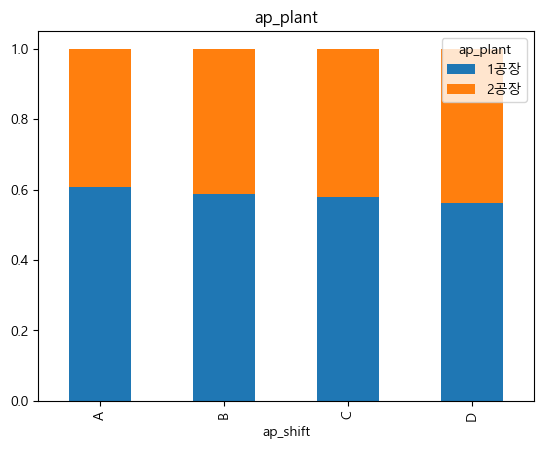

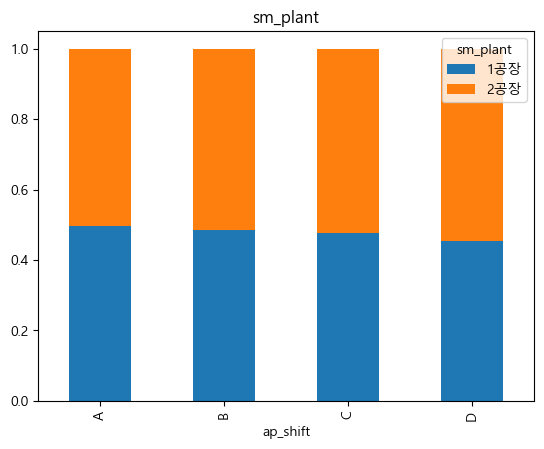

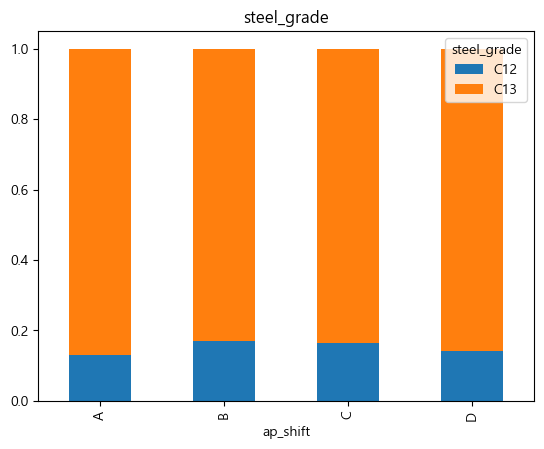

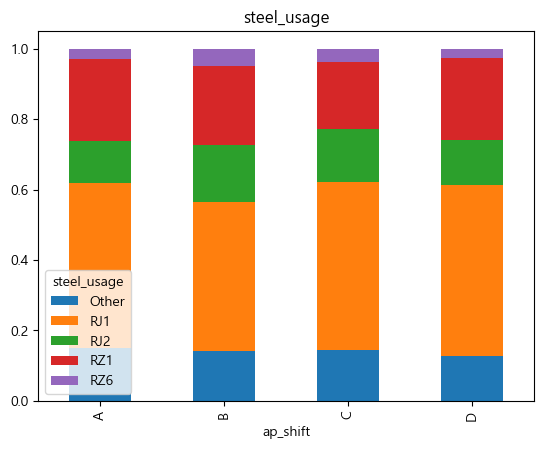

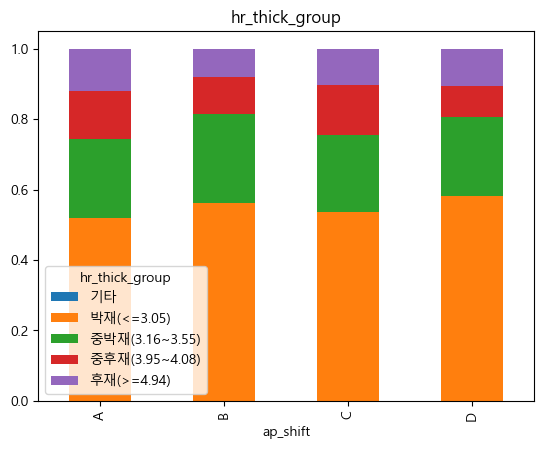

In [241]:
top5 = final_df_score.head(5)['variable']

for col in top5:
    if col in num_cols:
        sns.boxplot(x='ap_shift', y=col, data=df)
    else:
        pd.crosstab(df['ap_shift'], df[col], normalize='index').plot(kind='bar', stacked=True)
    
    plt.title(col)
    plt.show()

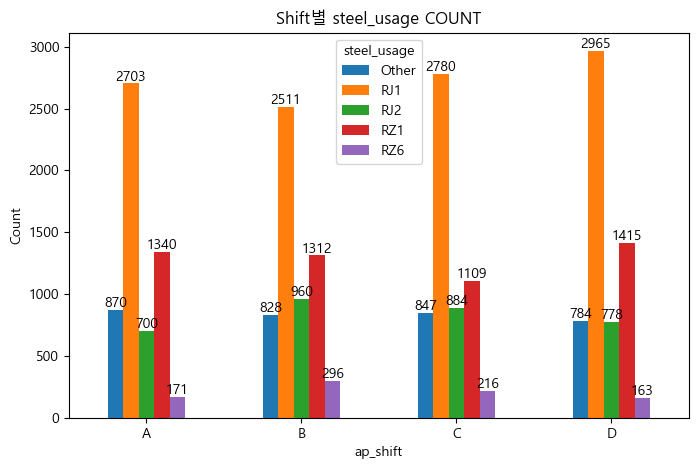

In [242]:
import matplotlib.pyplot as plt
import pandas as pd

count = pd.crosstab(df['ap_shift'], df['steel_usage'])

ax = count.plot(kind='bar', figsize=(8,5))

# 숫자 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Shift별 steel_usage COUNT')
plt.ylabel('Count')
plt.xlabel('ap_shift')
plt.xticks(rotation=0)

plt.show()

##gpt 뭔가 유의미 

In [243]:
b_df = df[df['ap_shift'] == 'B']
other_df = df[df['ap_shift'] != 'B']

num_cols = df.select_dtypes(include=['int64','float64']).columns

diff_list = []

for col in num_cols:
    b_mean = b_df[col].mean()
    other_mean = other_df[col].mean()
    
    diff = b_mean - other_mean
    
    diff_list.append((col, b_mean, other_mean, diff))

diff_df = pd.DataFrame(diff_list, columns=['variable','B_mean','Other_mean','diff'])
diff_df = diff_df.sort_values('diff', key=abs, ascending=False)

print(diff_df.head(6))

          variable       B_mean   Other_mean      diff
7    f_jangip_temp   261.584730   265.352384 -3.767654
25      slab_width  1158.699509  1155.390014  3.309495
22        hr_width  1160.275775  1157.068265  3.207509
27        ap_width  1164.895378  1161.952666  2.942713
6          slab_no   348.633316   350.610719 -1.977403
17  f_pre_interval    90.421026    89.569986  0.851040



📊 f_jangip_temp 결과
  ap_shift        mean  count
0        A  263.829184   5784
1        B  261.584730   5907
2        C  266.899246   5836
3        D  265.316790   6105


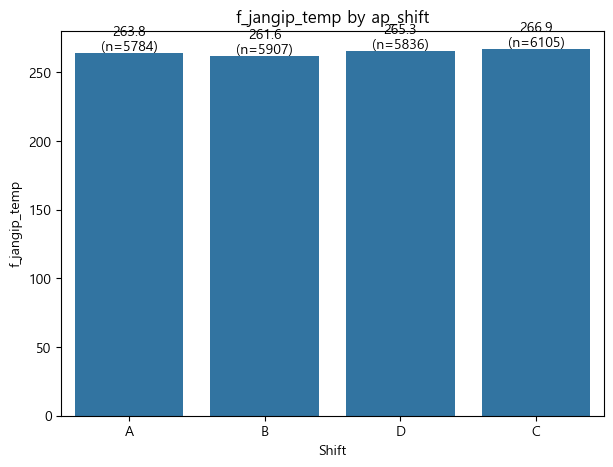


📊 slab_width 결과
  ap_shift         mean  count
0        A  1159.774723   5784
1        B  1158.699509   5907
2        C  1158.559287   5836
3        D  1148.206224   6105


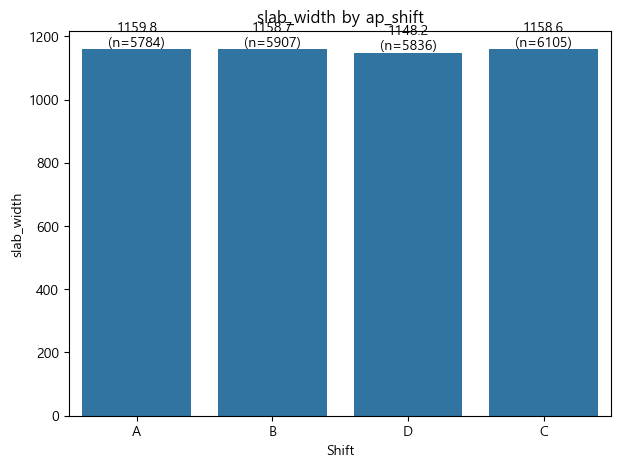


📊 hr_width 결과
  ap_shift         mean  count
0        A  1161.653008   5784
1        B  1160.275775   5907
2        C  1160.130569   5836
3        D  1149.797215   6105


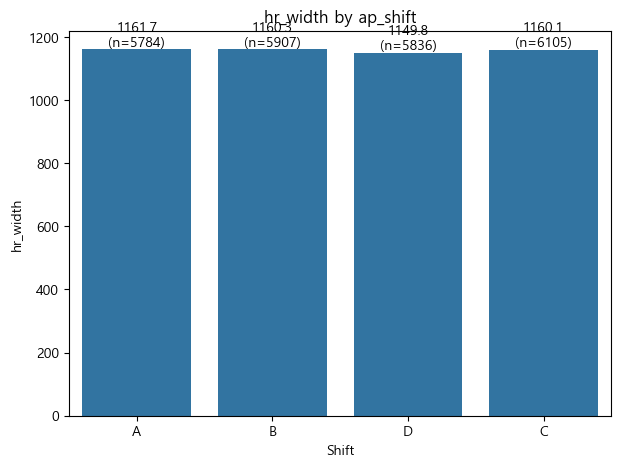


📊 ap_width 결과
  ap_shift         mean  count
0        A  1165.764869   5784
1        B  1164.895378   5907
2        C  1165.502742   5836
3        D  1154.947256   6105


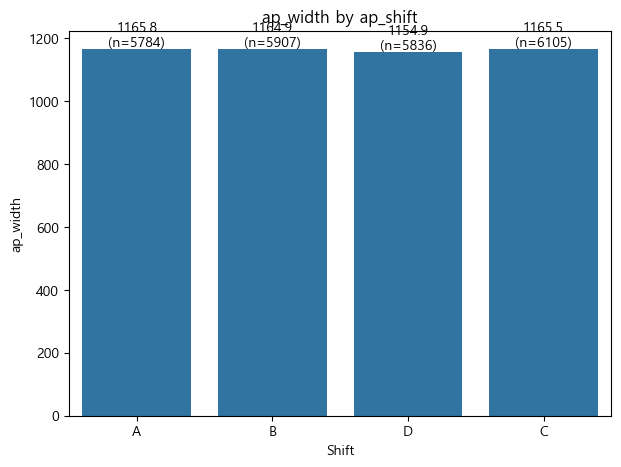


📊 slab_no 결과
  ap_shift        mean  count
0        A  347.946750   5784
1        B  348.633316   5907
2        C  352.209733   5836
3        D  351.606061   6105


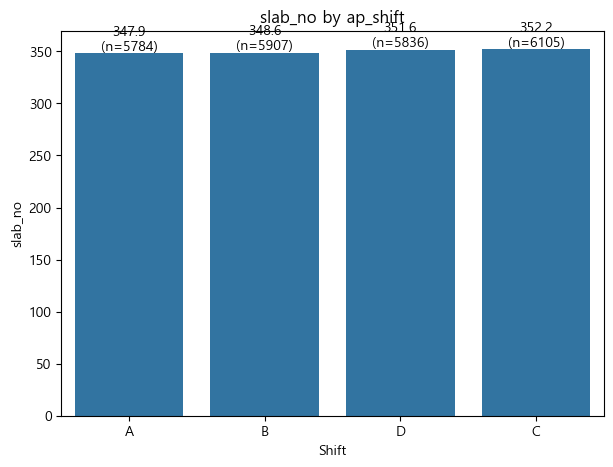


📊 f_pre_interval 결과
  ap_shift       mean  count
0        A  89.444848   5784
1        B  90.421026   5907
2        C  88.728410   5836
3        D  90.493038   6105


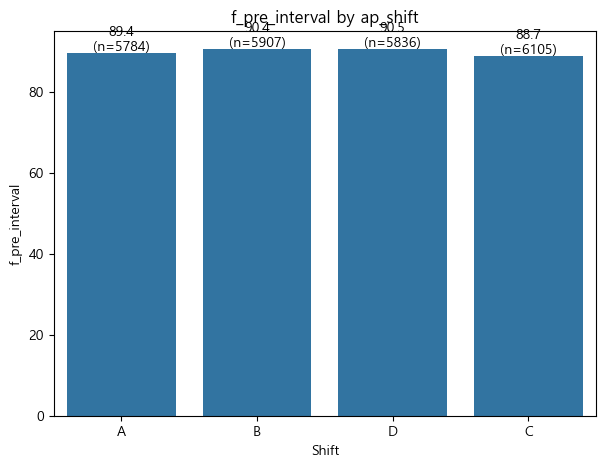

In [244]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 변수 6개 (니가 뽑은 거 그대로 넣으면 됨)
top_vars = ['f_jangip_temp','slab_width','hr_width','ap_width','slab_no','f_pre_interval']

for col in top_vars:
    
    print(f"\n📊 {col} 결과")
    
    # 1️⃣ 통계표 생성
    summary = df.groupby('ap_shift')[col].agg(['mean','count']).reset_index()
    print(summary)
    
    # 2️⃣ 그래프
    plt.figure(figsize=(7,5))
    
    ax = sns.barplot(x='ap_shift', y=col, data=df, ci=None)
    
    # 3️⃣ 숫자 표시 (mean + count 같이)
    for i, p in enumerate(ax.patches):
        mean_val = p.get_height()
        count_val = summary.loc[i, 'count']
        
        ax.annotate(f'{mean_val:.1f}\n(n={count_val})',
                    (p.get_x() + p.get_width()/2, mean_val),
                    ha='center', va='bottom', fontsize=10)
    
    plt.title(f'{col} by ap_shift')
    plt.xlabel('Shift')
    plt.ylabel(col)
    
    plt.show()


📊 f_jangip_temp
  ap_shift        mean  count
0        A  263.829184   5784
1        B  261.584730   5907
2        C  266.899246   5836
3        D  265.316790   6105


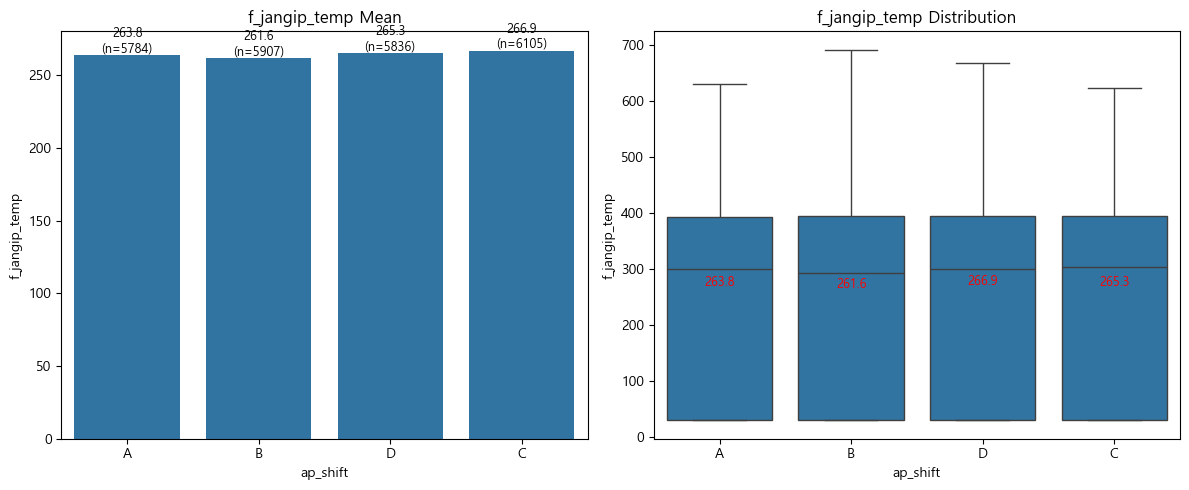


📊 slab_width
  ap_shift         mean  count
0        A  1159.774723   5784
1        B  1158.699509   5907
2        C  1158.559287   5836
3        D  1148.206224   6105


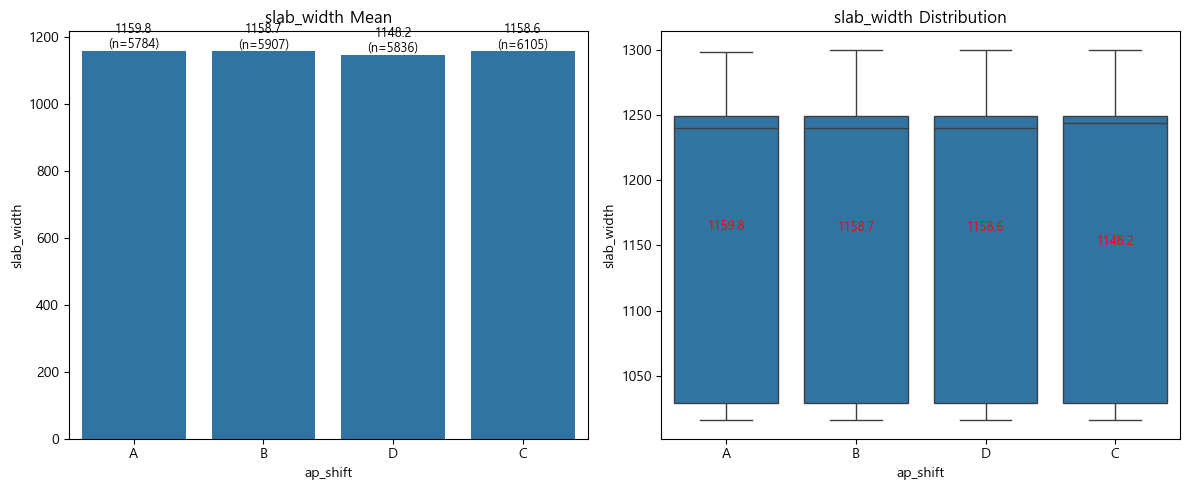


📊 hr_width
  ap_shift         mean  count
0        A  1161.653008   5784
1        B  1160.275775   5907
2        C  1160.130569   5836
3        D  1149.797215   6105


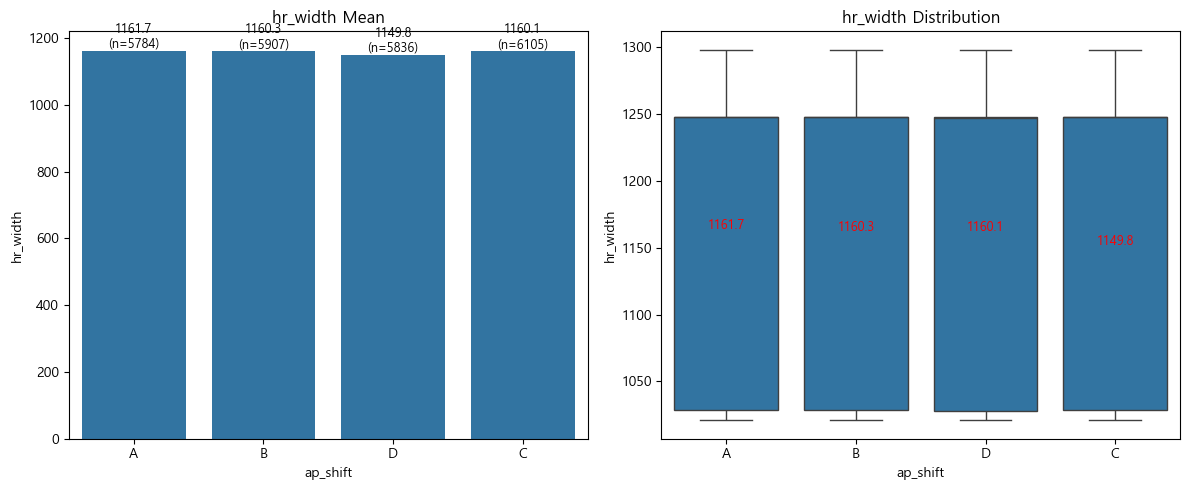


📊 ap_width
  ap_shift         mean  count
0        A  1165.764869   5784
1        B  1164.895378   5907
2        C  1165.502742   5836
3        D  1154.947256   6105


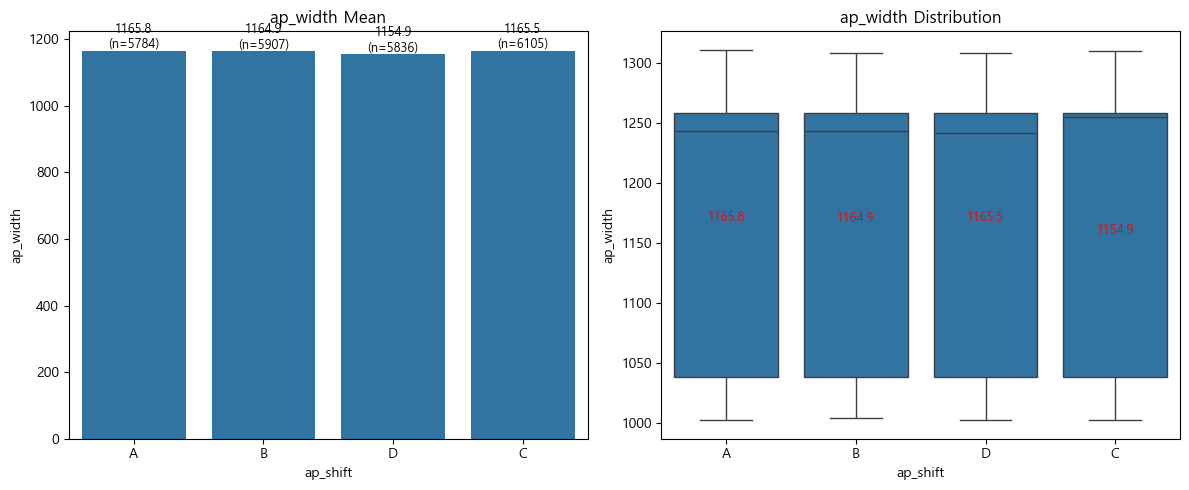


📊 slab_no
  ap_shift        mean  count
0        A  347.946750   5784
1        B  348.633316   5907
2        C  352.209733   5836
3        D  351.606061   6105


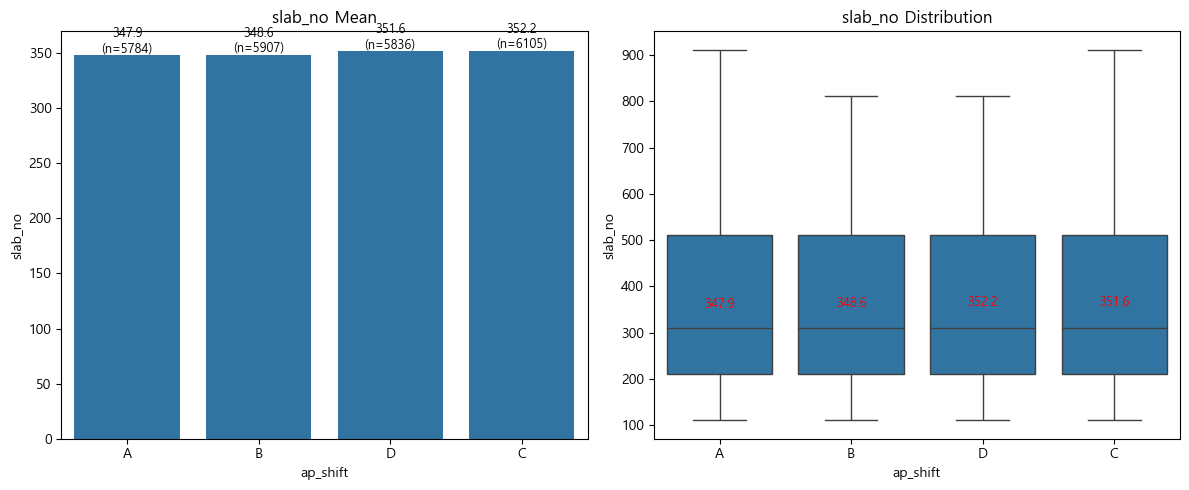


📊 f_pre_interval
  ap_shift       mean  count
0        A  89.444848   5784
1        B  90.421026   5907
2        C  88.728410   5836
3        D  90.493038   6105


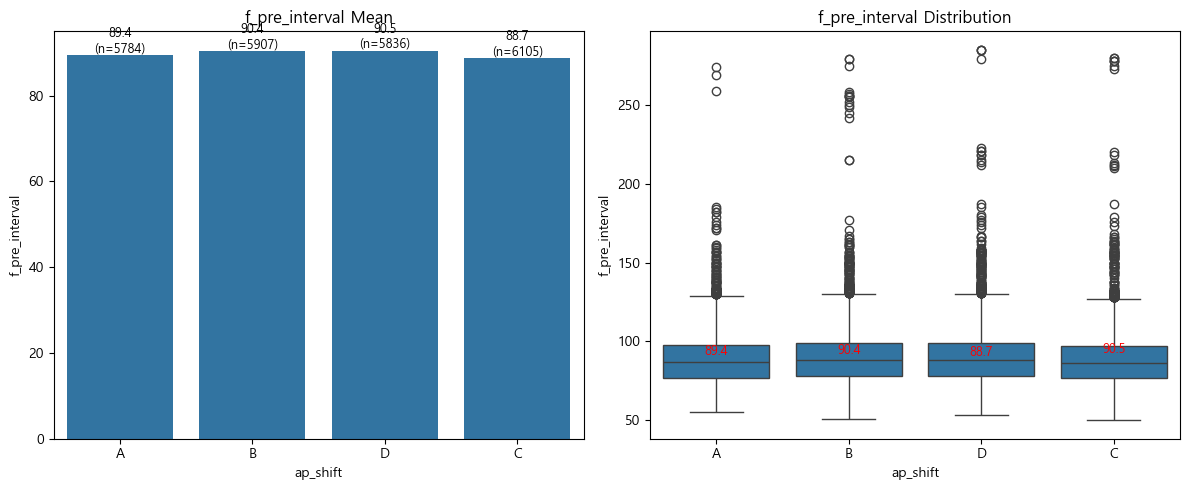

In [245]:
import matplotlib.pyplot as plt
import seaborn as sns

top_vars = ['f_jangip_temp','slab_width','hr_width','ap_width','slab_no','f_pre_interval']

for col in top_vars:
    
    print(f"\n📊 {col}")
    
    summary = df.groupby('ap_shift')[col].agg(['mean','count']).reset_index()
    print(summary)
    
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    
    # 🔵 1. BARPLOT (평균)
    ax1 = sns.barplot(x='ap_shift', y=col, data=df, ci=None, ax=axes[0])
    
    for i, p in enumerate(ax1.patches):
        mean_val = p.get_height()
        count_val = summary.loc[i, 'count']
        
        ax1.annotate(f'{mean_val:.1f}\n(n={count_val})',
                     (p.get_x() + p.get_width()/2, mean_val),
                     ha='center', va='bottom', fontsize=9)
    
    ax1.set_title(f'{col} Mean')
    
    
    # 🔴 2. BOXPLOT (분포)
    sns.boxplot(x='ap_shift', y=col, data=df, ax=axes[1])
    
    # 평균값도 같이 찍기
    means = df.groupby('ap_shift')[col].mean()
    for i, val in enumerate(means):
        axes[1].text(i, val, f'{val:.1f}', 
                     ha='center', va='bottom', color='red', fontsize=9)
    
    axes[1].set_title(f'{col} Distribution')
    
    plt.tight_layout()
    plt.show()

#범주형변수와 비교

In [246]:
cat_cols = df.select_dtypes(include='object').columns

cat_result = []

for col in cat_cols:
    if col == 'ap_shift':
        continue
    
    ratio = pd.crosstab(df['ap_shift'], df[col], normalize='index')
    
    if 'B' in ratio.index:
        b_ratio = ratio.loc['B']
        other_ratio = ratio.drop('B').mean()
        
        diff = (b_ratio - other_ratio).abs().mean()
        
        cat_result.append((col, diff))

cat_df = pd.DataFrame(cat_result, columns=['variable','diff'])
cat_df = cat_df.sort_values('diff', ascending=False)

print(cat_df.head(5))

          variable      diff
2      steel_grade  0.025698
3      steel_usage  0.021004
12  hr_thick_group  0.018253
8   f_jangip_gubun  0.017373
13           judge  0.013980



📊 steel_grade
▶ COUNT
steel_grade   C12   C13
ap_shift               
A             746  5038
B            1007  4900
C             959  4877
D             861  5244

▶ RATIO (%)
steel_grade    C12    C13
ap_shift                 
A            12.90  87.10
B            17.05  82.95
C            16.43  83.57
D            14.10  85.90


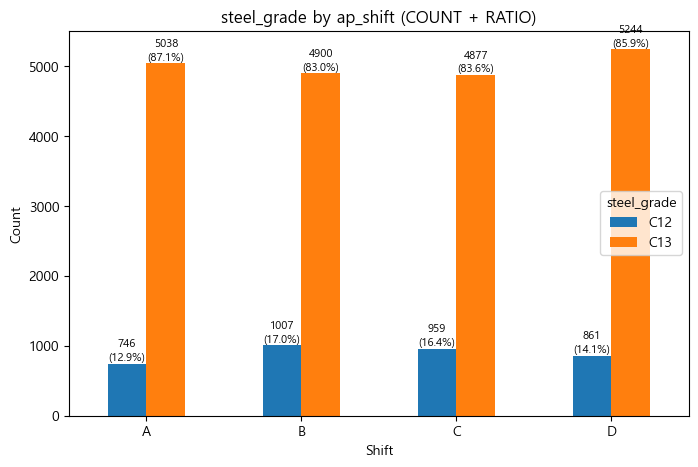


📊 steel_usage
▶ COUNT
steel_usage  Other   RJ1  RJ2   RZ1  RZ6
ap_shift                                
A              870  2703  700  1340  171
B              828  2511  960  1312  296
C              847  2780  884  1109  216
D              784  2965  778  1415  163

▶ RATIO (%)
steel_usage  Other    RJ1    RJ2    RZ1   RZ6
ap_shift                                     
A            15.04  46.73  12.10  23.17  2.96
B            14.02  42.51  16.25  22.21  5.01
C            14.51  47.64  15.15  19.00  3.70
D            12.84  48.57  12.74  23.18  2.67


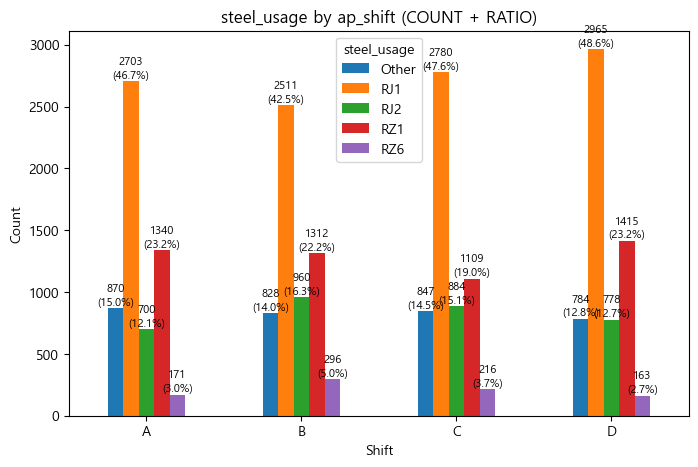


📊 hr_thick_group
▶ COUNT
hr_thick_group  기타  박재(<=3.05)  중박재(3.16~3.55)  중후재(3.95~4.08)  후재(>=4.94)
ap_shift                                                                  
A                1        3005            1291             794         693
B                0        3317            1490             620         480
C                2        3122            1287             827         598
D                1        3548            1374             528         654

▶ RATIO (%)
hr_thick_group    기타  박재(<=3.05)  중박재(3.16~3.55)  중후재(3.95~4.08)  후재(>=4.94)
ap_shift                                                                    
A               0.02       51.95           22.32           13.73       11.98
B               0.00       56.15           25.22           10.50        8.13
C               0.03       53.50           22.05           14.17       10.25
D               0.02       58.12           22.51            8.65       10.71


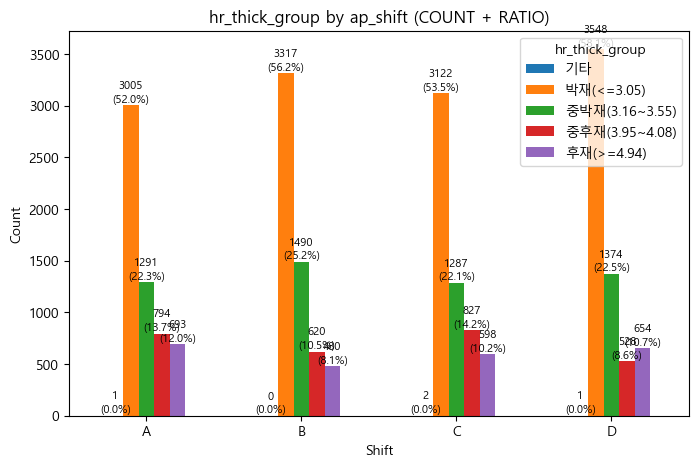


📊 f_jangip_gubun
▶ COUNT
f_jangip_gubun   CCR   HCR
ap_shift                  
A               2871  2913
B               3033  2874
C               2874  2962
D               3049  3056

▶ RATIO (%)
f_jangip_gubun    CCR    HCR
ap_shift                    
A               49.64  50.36
B               51.35  48.65
C               49.25  50.75
D               49.94  50.06


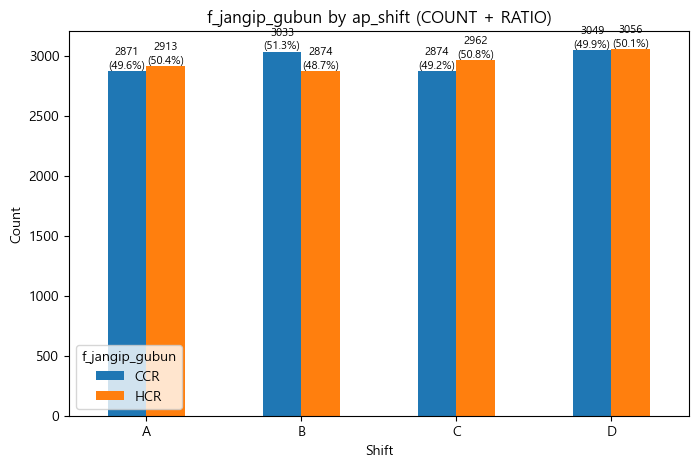

In [247]:
import matplotlib.pyplot as plt
import pandas as pd

# Top4 범주형 변수
top_cat = ['steel_grade','steel_usage','hr_thick_group','f_jangip_gubun']

for col in top_cat:
    
    print(f"\n📊 {col}")
    
    # COUNT & RATIO 계산
    count = pd.crosstab(df['ap_shift'], df[col])
    ratio = pd.crosstab(df['ap_shift'], df[col], normalize='index')
    
    print("▶ COUNT")
    print(count)
    
    print("\n▶ RATIO (%)")
    print((ratio*100).round(2))
    
    # 그래프
    ax = count.plot(kind='bar', figsize=(8,5))
    
    # 숫자 + 비율 같이 표시
    for i, container in enumerate(ax.containers):
        for j, bar in enumerate(container):
            height = bar.get_height()
            r = ratio.iloc[j, i]
            
            ax.text(bar.get_x() + bar.get_width()/2,
                    height,
                    f'{int(height)}\n({r*100:.1f}%)',
                    ha='center', va='bottom', fontsize=8)
    
    plt.title(f'{col} by ap_shift (COUNT + RATIO)')
    plt.xlabel('Shift')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    
    plt.show()

In [248]:
#유의미한거 장입구분, 

In [249]:
b_defect = df[(df['ap_shift']=='B') & (df['judge']=='불량')]
b_normal = df[(df['ap_shift']=='B') & (df['judge']=='양품')]

result = []

for col in num_cols:
    diff = b_defect[col].mean() - b_normal[col].mean()
    result.append((col, diff))

res_df = pd.DataFrame(result, columns=['variable','diff'])
res_df = res_df.sort_values('diff', key=abs, ascending=False)

print(res_df.head(5))

          variable        diff
7    f_jangip_temp -162.419150
6          slab_no   24.934975
17  f_pre_interval    5.779550
22        hr_width    4.910860
25      slab_width    4.029803


In [250]:

# B조 불량은 장입 온도 저하와 공정 간 대기시간 증가로 인한 열 손실, 
# 그리고 소재 폭에 따른 열 분포 불균일이 복합적으로 작용하여 발생한 것으로 판단된다.
# B조 불량품과 정삼품의 차이(평균차이)를 본건데 가장 큰 거임. 
#근데 이건 비약이 있을지도. B조가 어떤 규격의 어떤 물질의 어떤 필요한 조건을 하는지 모르니까

In [251]:
cat_cols = df.select_dtypes(include='object').columns

b_defect = df[(df['ap_shift']=='B') & (df['judge']=='불량')]
b_normal = df[(df['ap_shift']=='B') & (df['judge']=='양품')]

cat_result = []

for col in cat_cols:
    if col in ['ap_shift','judge']:
        continue
    
    # 비율 계산
    defect_ratio = b_defect[col].value_counts(normalize=True)
    normal_ratio = b_normal[col].value_counts(normalize=True)
    
    # 공통 index 맞추기
    all_index = defect_ratio.index.union(normal_ratio.index)
    
    defect_ratio = defect_ratio.reindex(all_index, fill_value=0)
    normal_ratio = normal_ratio.reindex(all_index, fill_value=0)
    
    # 차이 계산
    diff = (defect_ratio - normal_ratio).abs().mean()
    
    cat_result.append((col, diff))

cat_df = pd.DataFrame(cat_result, columns=['variable','diff'])
cat_df = cat_df.sort_values('diff', ascending=False)

print(cat_df.head(5))

          variable      diff
8   f_jangip_gubun  0.353530
0         sm_plant  0.115374
12  hr_thick_group  0.059220
6       slab_grind  0.053439
13        ap_plant  0.049619


In [252]:
#마찬가지로 B조에서 불량과 양품 차이(개수)를 본거임
#1위는 장입구분이므로 확정
#2위는 sm_plant


#근데 이것도 약간의 비약이 있으나, 일단 넣어봄


📊 f_jangip_gubun (B조 기준)
▶ COUNT
judge            불량    양품
f_jangip_gubun           
CCR             187  2846
HCR              32  2842

▶ RATIO (%)
judge             불량     양품
f_jangip_gubun             
CCR             6.17  93.83
HCR             1.11  98.89


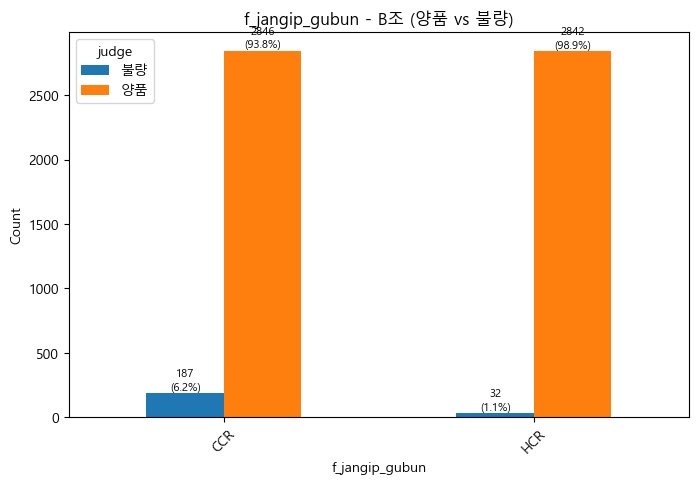


📊 sm_plant (B조 기준)
▶ COUNT
judge      불량    양품
sm_plant           
1공장        82  2786
2공장       137  2902

▶ RATIO (%)
judge       불량     양품
sm_plant             
1공장       2.86  97.14
2공장       4.51  95.49


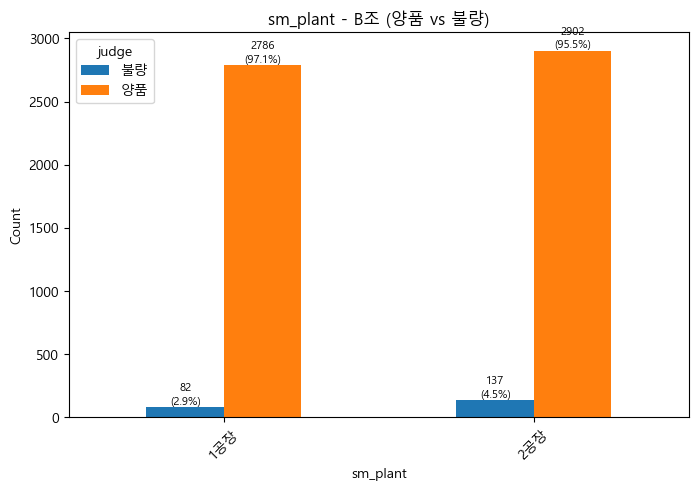


📊 hr_thick_group (B조 기준)
▶ COUNT
judge           불량    양품
hr_thick_group          
박재(<=3.05)      98  3219
중박재(3.16~3.55)  60  1430
중후재(3.95~4.08)  29   591
후재(>=4.94)      32   448

▶ RATIO (%)
judge             불량     양품
hr_thick_group             
박재(<=3.05)      2.95  97.05
중박재(3.16~3.55)  4.03  95.97
중후재(3.95~4.08)  4.68  95.32
후재(>=4.94)      6.67  93.33


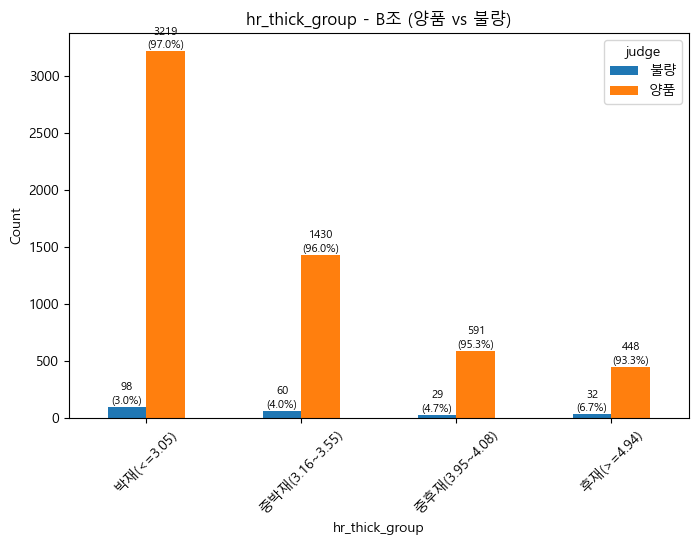


📊 slab_grind (B조 기준)
▶ COUNT
judge        불량    양품
slab_grind           
HS            0     1
HSHS        150  2984
MISS         69  2700
MP            0     1
MPMP          0     1
MSMS          0     1

▶ RATIO (%)
judge         불량      양품
slab_grind              
HS          0.00  100.00
HSHS        4.79   95.21
MISS        2.49   97.51
MP          0.00  100.00
MPMP        0.00  100.00
MSMS        0.00  100.00


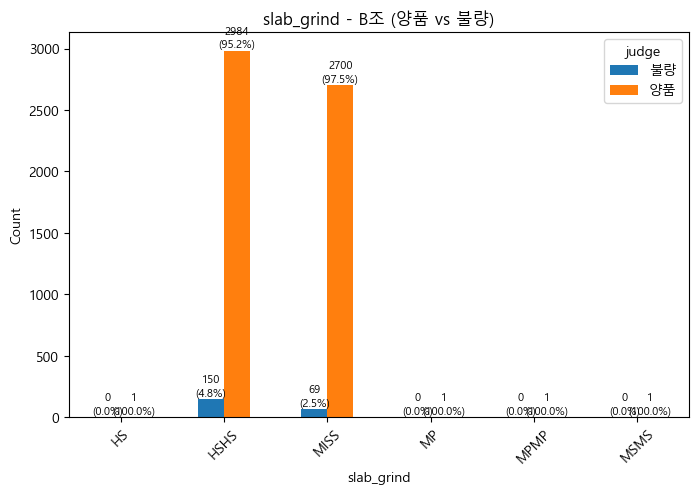


📊 ap_plant (B조 기준)
▶ COUNT
judge      불량    양품
ap_plant           
1공장       118  3347
2공장       101  2341

▶ RATIO (%)
judge       불량     양품
ap_plant             
1공장       3.41  96.59
2공장       4.14  95.86


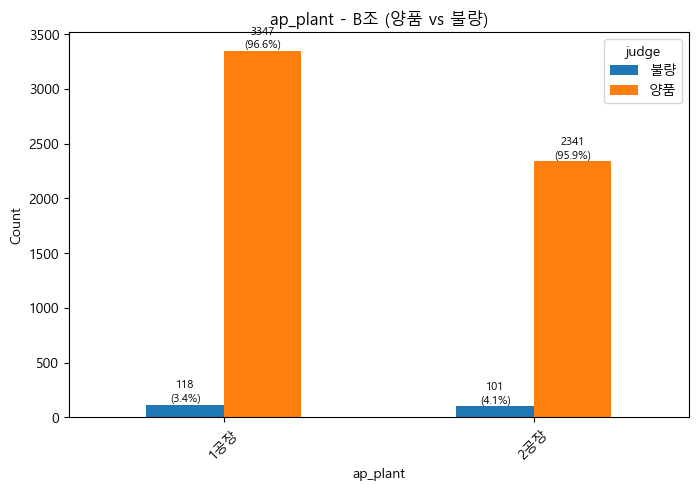

In [253]:
import matplotlib.pyplot as plt
import pandas as pd

# B조 데이터만
b_df = df[df['ap_shift']=='B']

top_cat = ['f_jangip_gubun','sm_plant','hr_thick_group','slab_grind','ap_plant']

for col in top_cat:
    
    print(f"\n📊 {col} (B조 기준)")
    
    # COUNT & RATIO
    count = pd.crosstab(b_df[col], b_df['judge'])
    ratio = pd.crosstab(b_df[col], b_df['judge'], normalize='index')
    
    print("▶ COUNT")
    print(count)
    
    print("\n▶ RATIO (%)")
    print((ratio*100).round(2))
    
    # 그래프
    ax = count.plot(kind='bar', figsize=(8,5))
    
    # 숫자 + 비율 표시
    for i, container in enumerate(ax.containers):
        for j, bar in enumerate(container):
            height = bar.get_height()
            r = ratio.iloc[j, i]
            
            ax.text(bar.get_x() + bar.get_width()/2,
                    height,
                    f'{int(height)}\n({r*100:.1f}%)',
                    ha='center', va='bottom', fontsize=8)
    
    plt.title(f'{col} - B조 (양품 vs 불량)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    plt.show()

In [254]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23632 entries, 0 to 23631
Data columns (total 59 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   sm_plant             23632 non-null  object        
 1   charge_id            23632 non-null  object        
 2   steel_grade          23632 non-null  object        
 3   steel_usage          23632 non-null  object        
 4   delta_ferrite        23632 non-null  float64       
 5   ingre_cr             23632 non-null  float64       
 6   ingre_ni             23632 non-null  float64       
 7   ingre_s              23632 non-null  float64       
 8   cast_date            23632 non-null  datetime64[ns]
 9   cc_gubun             23632 non-null  object        
 10  tundish_temp         23632 non-null  float64       
 11  mlac_ratio           23632 non-null  float64       
 12  slab_no              23632 non-null  int64         
 13  slab_gubun           23632 non-

In [255]:
import numpy as np

# 🔴 문제 구간 정의
cond_problem = (
    ((df['hr_width'] >= 1000) & (df['hr_width'] <= 1100)) |
    ((df['hr_width'] >= 1200) & (df['hr_width'] <= 1300))
)

# zone 생성
df['zone'] = np.where(cond_problem, 'problem_zone', 'normal_zone')

# 🔥 judge 정리 (중요)
df['judge'] = df['judge'].str.strip()

# 1️⃣ COUNT
count = pd.crosstab(df['zone'], df['judge'])

# 2️⃣ 불량률 (%)
ratio = pd.crosstab(df['zone'], df['judge'], normalize='index') * 100

# 3️⃣ 전체 불량률
total_defect_rate = (df['judge'] == '불량').sum() / len(df) * 100

# 4️⃣ 문제 구간 제거
df_filtered = df[df['zone'] == 'normal_zone']

# 🔥 여기 수정 (nan 방지)
filtered_defect_rate = (
    (df_filtered['judge'] == '불량').sum() / len(df_filtered) * 100
    if len(df_filtered) > 0 else 0
)

# 5️⃣ 개선율
improvement = total_defect_rate - filtered_defect_rate

# 🔥 출력
print("📊 구간별 COUNT")
print(count)

print("\n📊 구간별 불량률 (%)")
print(ratio.round(2))

print("\n📊 전체 불량률:", round(total_defect_rate, 2), "%")
print("📊 문제 구간 제거 후 불량률:", round(filtered_defect_rate, 2), "%")
print("🔥 개선된 불량률:", round(improvement, 2), "%")

📊 구간별 COUNT
judge          불량     양품
zone                    
problem_zone  629  23003

📊 구간별 불량률 (%)
judge           불량     양품
zone                     
problem_zone  2.66  97.34

📊 전체 불량률: 2.66 %
📊 문제 구간 제거 후 불량률: 0 %
🔥 개선된 불량률: 2.66 %


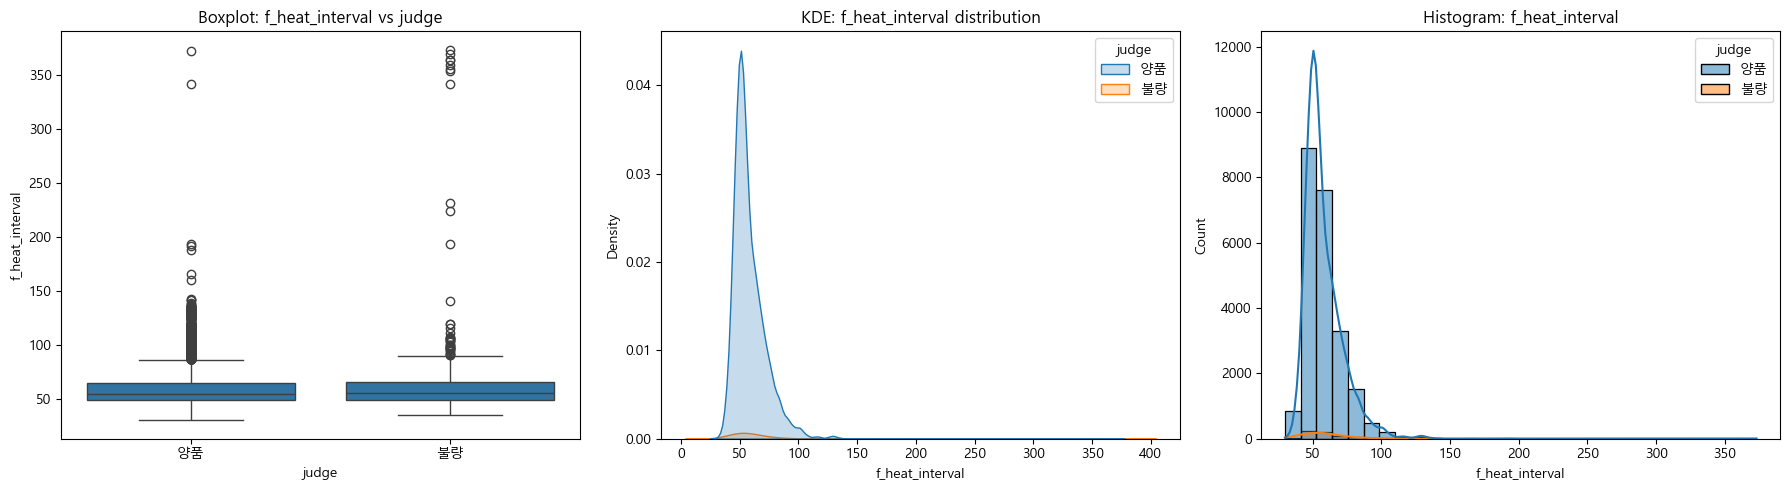

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,5))

# 1. BOXPLOT
plt.subplot(1,3,1)
sns.boxplot(x='judge', y='f_heat_interval', data=final_df)
plt.title('Boxplot: f_heat_interval vs judge')

# 2. KDE (밀도)
plt.subplot(1,3,2)
sns.kdeplot(data=final_df, x='f_heat_interval', hue='judge', fill=True)
plt.title('KDE: f_heat_interval distribution')

# 3. HISTOGRAM
plt.subplot(1,3,3)
sns.histplot(data=final_df, x='f_heat_interval', hue='judge', bins=30, kde=True)
plt.title('Histogram: f_heat_interval')

plt.tight_layout()
plt.show()

In [257]:
pd.crosstab(final_df['f_heat_interval'], final_df['judge'])

judge,불량,양품
f_heat_interval,,
30,0,2
31,0,4
32,0,4
33,0,11
34,0,16
...,...,...
359,1,0
364,2,0
369,1,0


In [258]:
# 구간 나누기
final_df['heat_bin'] = pd.cut(final_df['f_heat_interval'],
                             bins=10)  # 구간 개수 조절 가능

# COUNT 표
pd.crosstab(final_df['heat_bin'], final_df['judge'])

judge,불량,양품
heat_bin,,
"(29.657, 64.3]",466,17359
"(64.3, 98.6]",136,5284
"(98.6, 132.9]",15,333
"(132.9, 167.2]",1,22
"(167.2, 201.5]",1,3
"(201.5, 235.8]",2,0
"(338.7, 373.0]",8,2


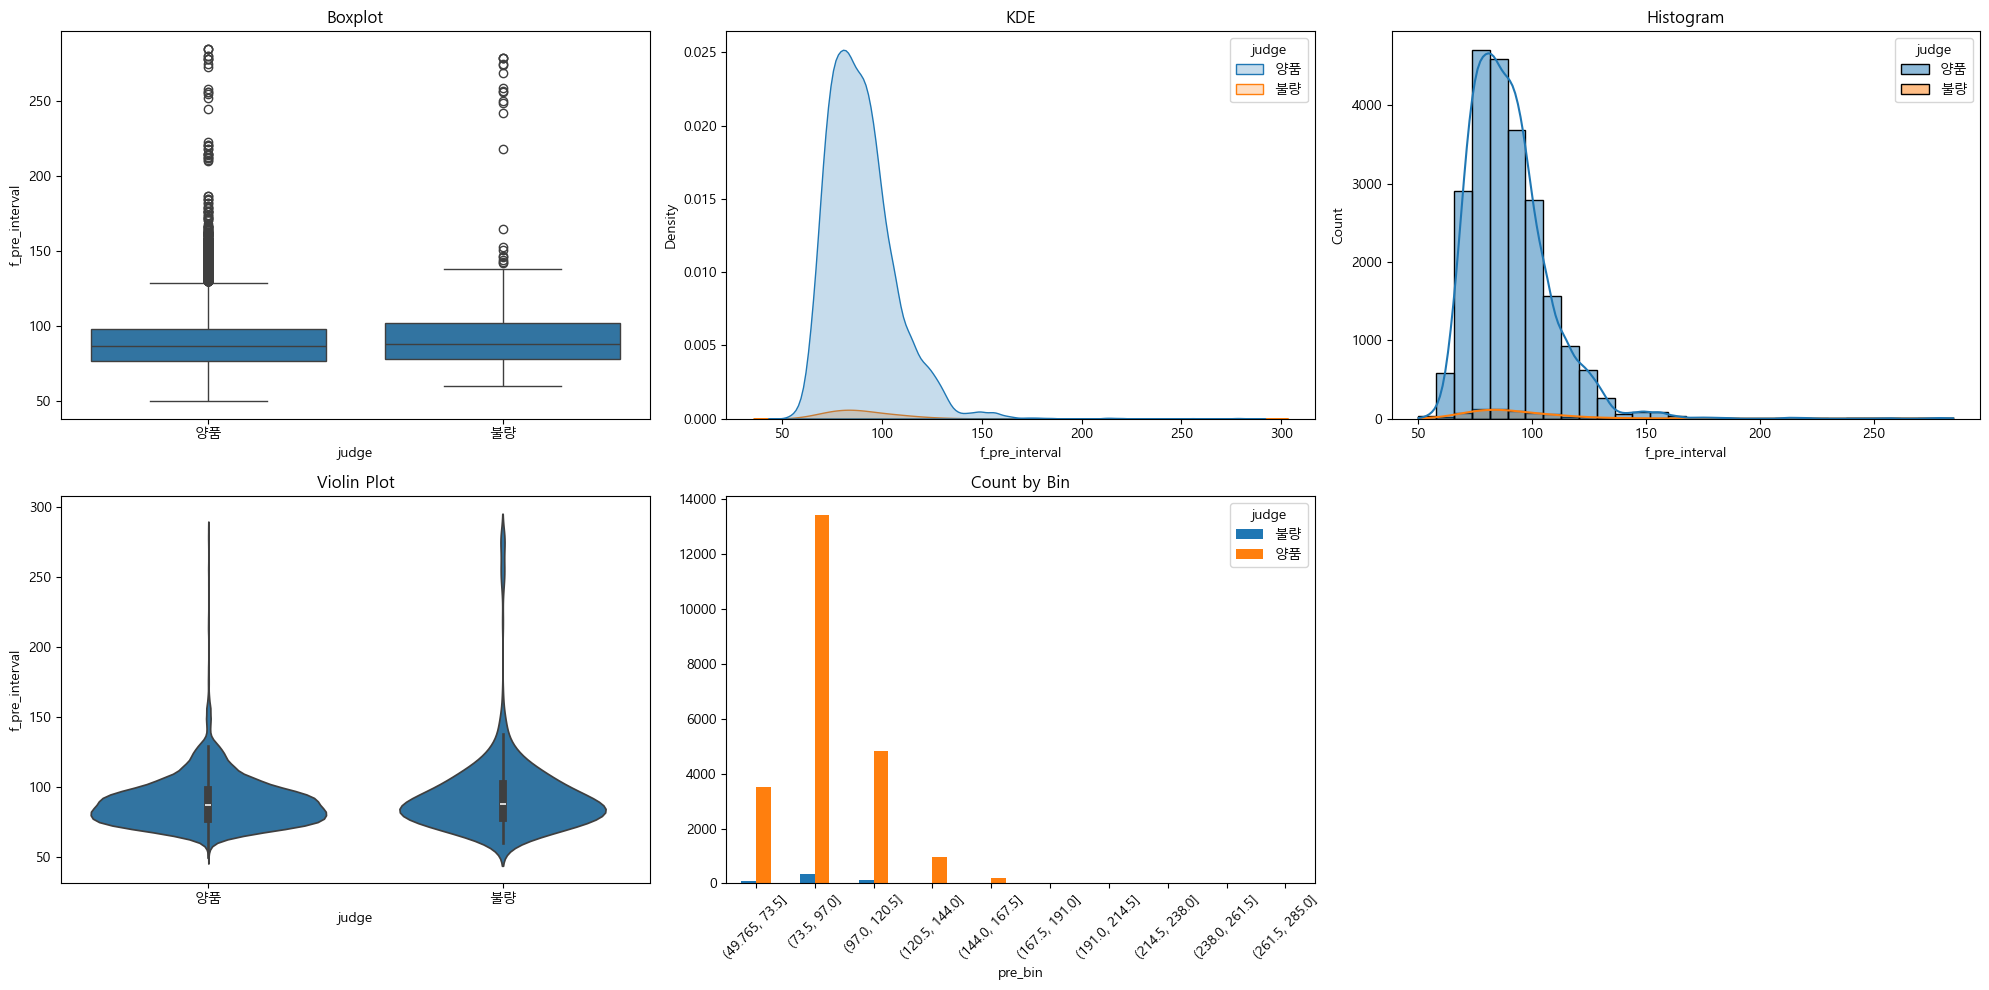

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(20,10))

# 1. Boxplot
plt.subplot(2,3,1)
sns.boxplot(x='judge', y='f_pre_interval', data=final_df)
plt.title('Boxplot')

# 2. KDE
plt.subplot(2,3,2)
sns.kdeplot(data=final_df, x='f_pre_interval', hue='judge', fill=True)
plt.title('KDE')

# 3. Histogram
plt.subplot(2,3,3)
sns.histplot(data=final_df, x='f_pre_interval', hue='judge', bins=30, kde=True)
plt.title('Histogram')

# 4. Violin plot
plt.subplot(2,3,4)
sns.violinplot(x='judge', y='f_pre_interval', data=final_df)
plt.title('Violin Plot')

# 5. Count (구간별)
final_df['pre_bin'] = pd.cut(final_df['f_pre_interval'], bins=10)

count_table = pd.crosstab(final_df['pre_bin'], final_df['judge'])

plt.subplot(2,3,5)
count_table.plot(kind='bar', ax=plt.gca())
plt.title('Count by Bin')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

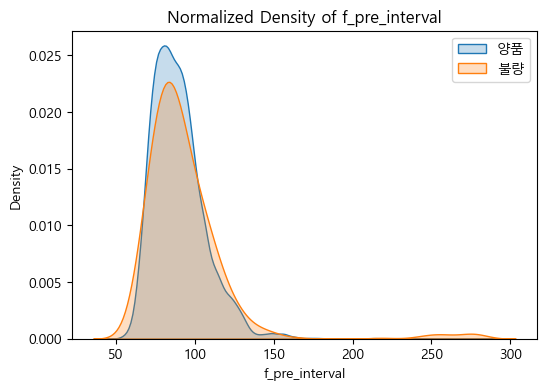

In [260]:
plt.figure(figsize=(6,4))

sns.kdeplot(data=final_df[final_df['judge']=='양품'],
            x='f_pre_interval', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'],
            x='f_pre_interval', label='불량', fill=True)

plt.title('Normalized Density of f_pre_interval')
plt.legend()
plt.show()

In [261]:
import numpy as np
from scipy.stats import gaussian_kde

# 데이터 분리
good = final_df[final_df['judge']=='양품']['f_pre_interval'].dropna()
bad = final_df[final_df['judge']=='불량']['f_pre_interval'].dropna()

# KDE 생성
kde_good = gaussian_kde(good)
kde_bad = gaussian_kde(bad)

# x 범위
x = np.linspace(min(final_df['f_pre_interval']), 
                max(final_df['f_pre_interval']), 1000)

# 밀도 계산
y_good = kde_good(x)
y_bad = kde_bad(x)

# 교점 찾기
diff = y_good - y_bad
cross_idx = np.where(np.diff(np.sign(diff)))[0]

intersection_points = x[cross_idx]
print("교점:", intersection_points)

교점: [ 67.17217217 101.51651652 153.5035035  164.32432432 171.85185185
 192.55255255]


In [262]:
threshold = intersection_points[0]
print("기준값:", threshold)

기준값: 67.17217217217217


In [263]:
# 왼쪽 구간만 필터
left_df = final_df[final_df['f_pre_interval'] < threshold].copy()

# 구간 나누기 (예: 4구간)
left_df['bin'] = pd.cut(left_df['f_pre_interval'], bins=4)

# 불량 count
count_table = pd.crosstab(left_df['bin'], left_df['judge'])

print(count_table)

judge            불량   양품
bin                     
(49.983, 54.25]   0    9
(54.25, 58.5]     0   38
(58.5, 62.75]     5  163
(62.75, 67.0]    24  840


In [264]:
print(count_table['불량'])

bin
(49.983, 54.25]     0
(54.25, 58.5]       0
(58.5, 62.75]       5
(62.75, 67.0]      24
Name: 불량, dtype: int64


In [265]:
# 교점 기준
threshold = intersection_points[0]

# 교점보다 조금 더 크게 (예: +20 정도 여유)
upper = threshold + 20  

# 해당 구간 데이터만 사용
target_df = final_df[
    (final_df['f_pre_interval'] >= final_df['f_pre_interval'].min()) &
    (final_df['f_pre_interval'] <= upper)
].copy()

# 10구간으로 나누기
target_df['bin'] = pd.cut(target_df['f_pre_interval'], bins=10)

# COUNT
count_table = pd.crosstab(target_df['bin'], target_df['judge'])

print(count_table)

# 🔥 불량만 보기
print("\n불량 COUNT:\n")
print(count_table['불량'])

judge           불량    양품
bin                     
(49.963, 53.7]   0     3
(53.7, 57.4]     0    30
(57.4, 61.1]     3   117
(61.1, 64.8]     9   284
(64.8, 68.5]    22   904
(68.5, 72.2]    45  1682
(72.2, 75.9]    38  1636
(75.9, 79.6]    62  2333
(79.6, 83.3]    67  2408
(83.3, 87.0]    63  2306

불량 COUNT:

bin
(49.963, 53.7]     0
(53.7, 57.4]       0
(57.4, 61.1]       3
(61.1, 64.8]       9
(64.8, 68.5]      22
(68.5, 72.2]      45
(72.2, 75.9]      38
(75.9, 79.6]      62
(79.6, 83.3]      67
(83.3, 87.0]      63
Name: 불량, dtype: int64


In [266]:
# 교점 기준
threshold = intersection_points[0]

# 교점보다 조금 더 크게
upper = threshold + 20  

# 구간 데이터
target_df = final_df[
    (final_df['f_pre_interval'] >= final_df['f_pre_interval'].min()) &
    (final_df['f_pre_interval'] <= upper)
].copy()

# 10구간 나누기
target_df['bin'] = pd.cut(target_df['f_pre_interval'], bins=10)

# COUNT 테이블
count_table = pd.crosstab(target_df['bin'], target_df['judge'])

# 🔥 불량률 계산
count_table['total'] = count_table.sum(axis=1)
count_table['defect_rate'] = count_table['불량'] / count_table['total']

print(count_table)

judge           불량    양품  total  defect_rate
bin                                         
(49.963, 53.7]   0     3      3     0.000000
(53.7, 57.4]     0    30     30     0.000000
(57.4, 61.1]     3   117    120     0.025000
(61.1, 64.8]     9   284    293     0.030717
(64.8, 68.5]    22   904    926     0.023758
(68.5, 72.2]    45  1682   1727     0.026057
(72.2, 75.9]    38  1636   1674     0.022700
(75.9, 79.6]    62  2333   2395     0.025887
(79.6, 83.3]    67  2408   2475     0.027071
(83.3, 87.0]    63  2306   2369     0.026593


In [267]:
# 조건 필터
df_40 = final_df[final_df['ap_line_speed'] == 40]

# 얇음 / 얇지 않음 개수
df_40['hr_thick_group'].value_counts()

hr_thick_group
중박재(3.16~3.55)    59
박재(<=3.05)        12
중후재(3.95~4.08)     7
Name: count, dtype: int64

In [268]:
thin_count = (df_40['hr_thick_group'] == '얇음').sum()
not_thin_count = (df_40['hr_thick_group'] != '얇음').sum()

print("얇음 개수:", thin_count)
print("얇지 않음 개수:", not_thin_count)

얇음 개수: 0
얇지 않음 개수: 78


In [269]:
pd.crosstab(df_40['hr_thick_group'], columns='count')


col_0,count
hr_thick_group,
박재(<=3.05),12
중박재(3.16~3.55),59
중후재(3.95~4.08),7


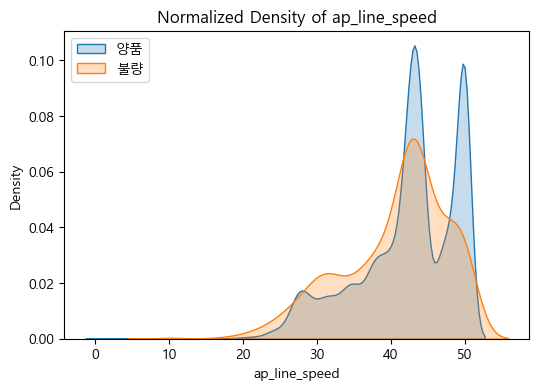

In [270]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.kdeplot(data=final_df[final_df['judge']=='양품'],
            x='ap_line_speed', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'],
            x='ap_line_speed', label='불량', fill=True)

plt.title('Normalized Density of ap_line_speed')
plt.xlabel('ap_line_speed')
plt.ylabel('Density')
plt.legend()

plt.show()

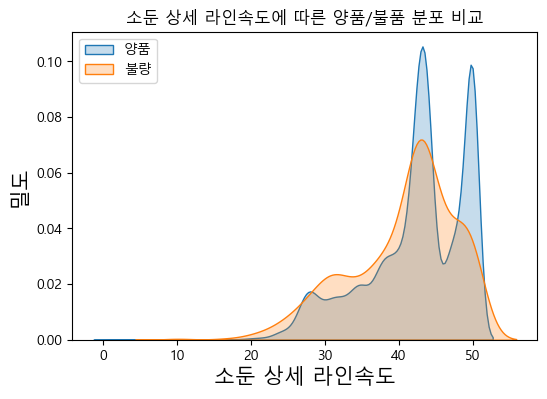

In [271]:
plt.figure(figsize=(6,4))

sns.kdeplot(data=final_df[final_df['judge']=='양품'],
            x='ap_line_speed', label='양품', fill=True)

sns.kdeplot(data=final_df[final_df['judge']=='불량'],
            x='ap_line_speed', label='불량', fill=True)

# 제목 & 축 설정
plt.title('소둔 상세 라인속도에 따른 양품/불품 분포 비교')
plt.xlabel('소둔 상세 라인속도', fontsize=15)
plt.ylabel('밀도', fontsize=15)

plt.legend()
plt.show()